# ðŸŒ«ï¸ AI-Powered Air Quality Intelligence & AQI Forecasting

### AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 | BharatCares
**Author:** Gaurav Rajbhar

---

## ðŸ“Œ Project Overview

Air pollution is a major public health and environmental concern in Indian cities.
The Central Pollution Control Board (CPCB) publishes daily pollutant concentration
data (PM2.5, PM10, NO2, SO2, CO, O3, etc.) along with a computed Air Quality Index
(AQI) for multiple cities across India.

This project builds an **end-to-end Air Quality Intelligence system** that goes
beyond a simple AQI prediction script. It combines:

- **Exploratory Data Analytics** â€” understanding pollutant behavior, seasonal
  patterns, and city-level differences.
- **Leakage-safe AQI Forecasting** â€” predicting next-day AQI using only
  information available before the prediction timestamp (lag features,
  rolling averages, temporal features).
- **Anomaly Detection** â€” using Isolation Forest to flag statistically unusual
  pollution readings.
- **Explainable AI (SHAP)** â€” interpreting which features drive the
  forecasting model's predictions.
- **Data-Driven Environmental Insights** â€” a final summary generated
  directly from computed results, not assumptions.

## ðŸŽ¯ Problem Statement

Air quality in Indian cities varies significantly across time and location,
driven by seasonal, meteorological, and anthropogenic factors. Simple
point-in-time pollutant monitoring is not enough â€” stakeholders need the
ability to **forecast near-future air quality**, **detect abnormal pollution
events**, and **understand which pollutants are driving the AQI**, in a
transparent and interpretable way.

## ðŸŽ¯ Objectives

1. Perform rigorous data quality analysis and cleaning on the CPCB city-level
   air quality dataset.
2. Conduct exploratory data analysis to understand pollutant distributions,
   correlations, and temporal/seasonal patterns.
3. Engineer leakage-safe temporal features (lags, rolling statistics) for
   forecasting.
4. Build and compare three forecasting models: a linear baseline, Random
   Forest, and XGBoost, using chronological (not random) train/test splits.
5. Detect anomalous pollution readings using Isolation Forest.
6. Explain the forecasting model's behavior using SHAP.
7. Summarize findings into a factual, data-driven Air Quality Intelligence
   report.

## ðŸ“ˆ Expected Outcomes

- A cleaned, well-understood air quality dataset.
- A working next-day AQI forecasting model with honest, real evaluation
  metrics (MAE, RMSE, RÂ²).
- A set of detected pollution anomalies with visualization.
- SHAP-based interpretation of model behavior.
- A final automated intelligence summary based on actual computed results.

---

## ðŸ—‚ï¸ Dataset

**Source:** Indian city-level air quality dataset (`city_day.csv`) â€” commonly
sourced from CPCB data via Kaggle. Exact columns and their quality are
verified programmatically in Section 5 (Dataset Understanding), and no
column is assumed to exist beforehand.

## ðŸ§° Technologies

Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, XGBoost, SHAP
(Google Colab environment).

## âš ï¸ Note on Methodology References

This project was informed by publicly available Indian AQI analytics/
forecasting repositories (e.g., `air_cast`, `air-aware`,
`AQI-Prediction-India-ComparativeStudy`) for understanding common dataset
structure and methodological pitfalls (e.g., temporal leakage). All code,
analysis, feature engineering choices, and conclusions in this notebook are
independently written and based on outputs actually generated from this
dataset.


## Table of Contents

1. Project Introduction & Objectives
2. Environment Setup
3. Load Dataset
4. Dataset Understanding
5. Data Quality Analysis
6. Data Cleaning
7. Exploratory Data Analysis
8. Pollutant Correlation & Distribution Analysis
9. Seasonal & Temporal Patterns
10. Time-Series Feature Engineering
11. Final Modeling Dataset & Chronological Train/Test Split
12. Baseline Model â€” Linear Regression
13. Random Forest Regressor
14. XGBoost Regressor
15. Model Evaluation & Comparison
16. Actual vs Predicted AQI
17. Anomaly Detection â€” Isolation Forest
18. Explainable AI â€” SHAP
19. Error Analysis
20. Air Quality Intelligence Summary
21. Limitations
22. Future Scope
23. Conclusion

In [1]:
# =========================================================
# ENVIRONMENT SETUP
# =========================================================

# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

print("Environment setup complete.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Environment setup complete.
Pandas version: 2.2.3
NumPy version: 2.1.3


In [2]:
# =========================================================
# LOAD DATASET VIA KAGGLEHUB
# =========================================================
import kagglehub

rohanrao_air_quality_data_in_india_path = kagglehub.dataset_download(
    'rohanrao/air-quality-data-in-india'
)

print("Dataset downloaded to:", rohanrao_air_quality_data_in_india_path)

# List files in the downloaded dataset folder
import os
print(os.listdir(rohanrao_air_quality_data_in_india_path))

Using Colab cache for faster access to the 'air-quality-data-in-india' dataset.
Dataset downloaded to: /kaggle/input/air-quality-data-in-india
['stations.csv', 'station_hour.csv', 'city_day.csv', 'city_hour.csv', 'station_day.csv']


In [3]:
# =========================================================
# READ city_day.csv
# =========================================================
import pandas as pd
import os

DATA_PATH = os.path.join(rohanrao_air_quality_data_in_india_path, "city_day.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (29531, 16)


## 5. Dataset Understanding

Before performing any cleaning or analysis, we inspect the dataset's actual
structure: its shape, columns, data types, missing values, duplicates, and
descriptive statistics. No assumptions are made about column names or
data quality until verified here.


In [4]:
# =========================================================
# FULL DATASET INSPECTION
# =========================================================

print("=" * 60)
print("SHAPE")
print("=" * 60)
print(df.shape)

print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(df.columns.tolist())

print("\n" + "=" * 60)
print("HEAD")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
print("Number of duplicate rows:", df.duplicated().sum())

print("\n" + "=" * 60)
print("DESCRIBE (ALL)")
print("=" * 60)
display(df.describe(include="all"))

SHAPE
(29531, 16)

COLUMN NAMES
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

HEAD


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN



INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB

MISSING VALUES
City              0
Date              0
PM2.5          4598
PM10          1114

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
count,29531,29531,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000,24850
unique,26,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,Ahmedabad,2020-03-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderate
freq,2009,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8829
mean,NaN,NaN,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581,NaN
std,NaN,NaN,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585,NaN
min,NaN,NaN,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000,NaN
25%,NaN,NaN,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000,NaN
50%,NaN,NaN,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000,NaN
75%,NaN,NaN,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000,NaN


## 6. Data Quality Analysis

Before cleaning, we investigate:
- Date parsing and date range
- City coverage (rows per city)
- Missing value percentages
- Relationship between missing AQI and missing AQI_Bucket
- AQI_Bucket categories
- Potential invalid/impossible values (negative pollutant readings)
- Extreme values / potential outliers

No data is removed or modified in this section â€” only investigated.

In [5]:
# =========================================================
# DATA QUALITY ANALYSIS
# =========================================================

# 1. Date parsing check
df['Date_parsed'] = pd.to_datetime(df['Date'], errors='coerce')
print("Rows where Date failed to parse:", df['Date_parsed'].isnull().sum())
print("Date range:", df['Date_parsed'].min(), "to", df['Date_parsed'].max())

# 2. City coverage
print("\nNumber of unique cities:", df['City'].nunique())
print("\nRows per city:")
print(df['City'].value_counts())

# 3. Missing value percentages
print("\nMissing value percentage per column:")
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_pct.sort_values(ascending=False))

# 4. Relationship between missing AQI and missing AQI_Bucket
print("\nRows where AQI is null but AQI_Bucket is NOT null:",
      ((df['AQI'].isnull()) & (df['AQI_Bucket'].notnull())).sum())
print("Rows where AQI_Bucket is null but AQI is NOT null:",
      ((df['AQI_Bucket'].isnull()) & (df['AQI'].notnull())).sum())

# 5. AQI_Bucket categories
print("\nAQI_Bucket unique categories:")
print(df['AQI_Bucket'].unique())

# 6. Check for negative values in pollutant columns (impossible for concentrations)
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
                   'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

print("\nNegative value counts per pollutant column:")
for col in pollutant_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"  {col}: {neg_count} negative values")
print("(No output above means no negative values found)")

# 7. Extreme value check (99th percentile vs max)
print("\n99th percentile vs Max value per pollutant:")
for col in pollutant_cols:
    p99 = df[col].quantile(0.99)
    max_val = df[col].max()
    print(f"  {col}: 99th pct = {p99:.2f}, max = {max_val:.2f}")

Rows where Date failed to parse: 0
Date range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00

Number of unique cities: 26

Rows per city:
City
Ahmedabad             2009
Bengaluru             2009
Chennai               2009
Mumbai                2009
Lucknow               2009
Delhi                 2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Kochi                  162
Ernakulam              162
Aizawl                 113
Name: count, dtype: int64

Missing value percentage per column:
Xylene         61.32
PM10           37.72
NH3            34.97
Toluene        27.23
Benzene   

### Interpretation â€” Data Quality Findings

- **Dates**: All 29,531 dates parsed successfully. Data spans **2015-01-01 to
  2020-07-01** (~5.5 years).
- **City coverage is uneven**: Cities like Ahmedabad, Bengaluru, Chennai,
  Mumbai, Lucknow, Delhi have ~2009 rows (near-complete daily coverage),
  while cities like Aizawl (113), Ernakulam/Kochi (162), Bhopal (289) have
  very limited data. This is a real limitation â€” forecasting and analysis
  will naturally be more reliable for cities with denser data.
- **Missing values are substantial for some pollutants**:
  - `Xylene` is missing in 61.32% of rows â€” too sparse to be a reliable
    predictor.
  - `PM10` (37.72%) and `NH3` (34.97%) also have high missingness.
  - `AQI` / `AQI_Bucket` are missing together in exactly the same rows
    (15.85%) â€” confirmed by the 0/0 cross-check â€” meaning AQI_Bucket is
    fully derived from AQI and there is no inconsistency between them.
- **No negative values** exist in any pollutant or AQI column â€” good sign,
  no
  

In [6]:
# =========================================================
# DATA CLEANING
# =========================================================

# Work on a copy to preserve the raw dataframe
df_clean = df.copy()

# 1. Replace Date with parsed datetime version, drop helper column
df_clean['Date'] = df_clean['Date_parsed']
df_clean = df_clean.drop(columns=['Date_parsed'])

# 2. Sort by City and Date (essential for all time-series operations)
df_clean = df_clean.sort_values(['City', 'Date']).reset_index(drop=True)

# 3. Drop Xylene (61.32% missing - unreliable)
df_clean = df_clean.drop(columns=['Xylene'])

# 4. Define pollutant columns (excluding AQI, which we won't impute)
pollutant_cols_to_impute = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
                             'CO', 'SO2', 'O3', 'Benzene', 'Toluene']

# 5. Per-city time-based linear interpolation
def interpolate_group(group):
    group = group.set_index('Date')
    group[pollutant_cols_to_impute] = group[pollutant_cols_to_impute].interpolate(
        method='time', limit_direction='both'
    )
    return group.reset_index()

df_clean = df_clean.groupby('City', group_keys=False).apply(interpolate_group)

# 6. Fill any remaining missing pollutant values with per-city median
for col in pollutant_cols_to_impute:
    df_clean[col] = df_clean.groupby('City')[col].transform(
        lambda x: x.fillna(x.median())
    )

# 7. Check remaining missing values
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nShape after cleaning:", df_clean.shape)

Missing values after cleaning:
Date             0
City             0
PM2.5            0
PM10          2009
NO               0
NO2              0
NOx           1169
NH3           2009
CO               0
SO2              0
O3             162
Benzene       2732
Toluene       4010
AQI           4681
AQI_Bucket    4681
dtype: int64

Shape after cleaning: (29531, 15)


In [7]:
# =========================================================
# DIAGNOSE REMAINING MISSING VALUES
# =========================================================

cols_with_missing = ['PM10', 'NOx', 'NH3', 'O3', 'Benzene', 'Toluene']

for col in cols_with_missing:
    print(f"\n--- {col} ---")
    missing_by_city = df_clean[df_clean[col].isnull()]['City'].value_counts()
    print(missing_by_city)


--- PM10 ---
City
Lucknow    2009
Name: count, dtype: int64

--- NOx ---
City
Jorapokhar    1169
Name: count, dtype: int64

--- NH3 ---
City
Ahmedabad    2009
Name: count, dtype: int64

--- O3 ---
City
Ernakulam    162
Name: count, dtype: int64

--- Benzene ---
City
Jorapokhar            1169
Thiruvananthapuram    1112
Bhopal                 289
Kochi                  162
Name: count, dtype: int64

--- Toluene ---
City
Jorapokhar            1169
Thiruvananthapuram    1112
Brajrajnagar           938
Guwahati               502
Bhopal                 289
Name: count, dtype: int64


### Interpretation

The remaining missing values are not random â€” they correspond to **entire
cities lacking a monitoring sensor for a specific pollutant** for the whole
recorded period (e.g., Lucknow has no PM10 readings at all; Ahmedabad has no
NH3 readings; Jorapokhar has no NOx, Benzene, or Toluene readings). This
reflects a genuine CPCB monitoring station limitation rather than random data
loss, and is documented as a limitation of this project.

Since per-city interpolation/median imputation cannot work when an entire
city's series is empty, we apply a **global median fallback** (computed
across all other cities) for these remaining gaps. This is a reasonable
last-resort strategy since these are the final few percent of missing values
after primary time-based imputation.

In [8]:
# =========================================================
# GLOBAL MEDIAN FALLBACK FOR REMAINING MISSING VALUES
# =========================================================

for col in pollutant_cols_to_impute:
    if df_clean[col].isnull().sum() > 0:
        global_median = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(global_median)

# Final check
print("Missing values after full cleaning:")
print(df_clean.isnull().sum())

print("\nShape:", df_clean.shape)

Missing values after full cleaning:
Date             0
City             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
AQI           4681
AQI_Bucket    4681
dtype: int64

Shape: (29531, 15)


## 8. Exploratory Data Analysis

For AQI-specific analysis, we use only rows where AQI is available
(`df_eda`), since imputing the target variable would be inappropriate.
Pollutant-level analysis can use the fully cleaned dataset where relevant.

We begin by examining the overall distribution of AQI and its categorical
buckets.


In [9]:
# =========================================================
# EDA SETUP - AQI SUBSET
# =========================================================

# Subset with valid AQI values only (for AQI-specific analysis)
df_eda = df_clean.dropna(subset=['AQI']).copy()

print("Rows with valid AQI:", df_eda.shape[0])
print("Date range in AQI subset:", df_eda['Date'].min(), "to", df_eda['Date'].max())
print("Cities with valid AQI data:", df_eda['City'].nunique())

Rows with valid AQI: 24850
Date range in AQI subset: 2015-01-01 00:00:00 to 2020-07-01 00:00:00
Cities with valid AQI data: 26


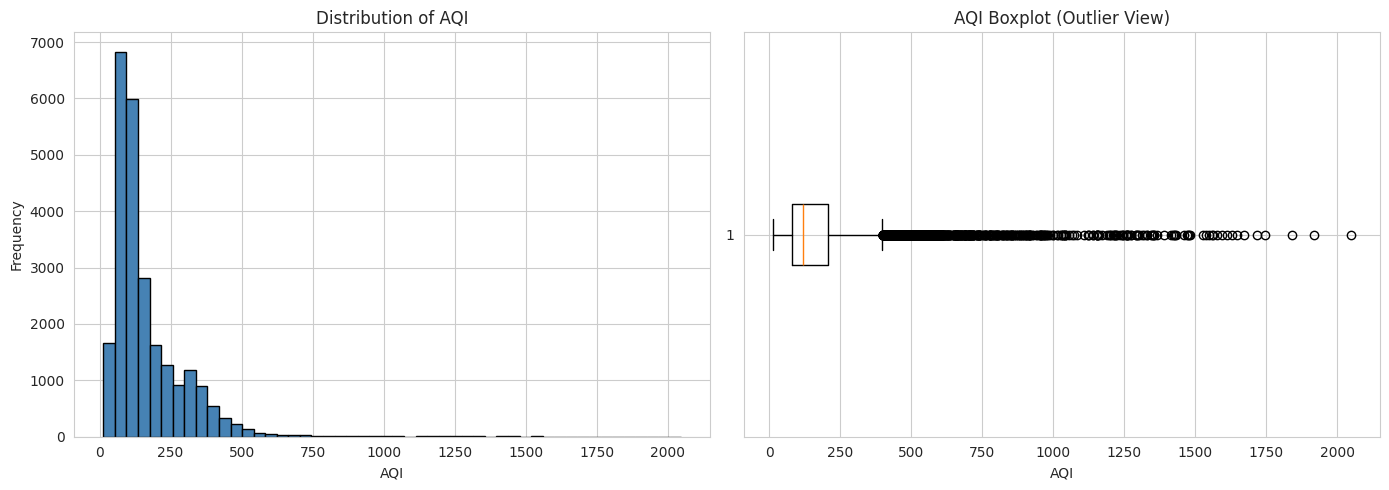

AQI Summary Statistics:
count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000
Name: AQI, dtype: float64


In [10]:
# =========================================================
# AQI DISTRIBUTION
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_eda['AQI'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of AQI')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df_eda['AQI'], vert=False)
axes[1].set_title('AQI Boxplot (Outlier View)')
axes[1].set_xlabel('AQI')

plt.tight_layout()
plt.show()

print("AQI Summary Statistics:")
print(df_eda['AQI'].describe())

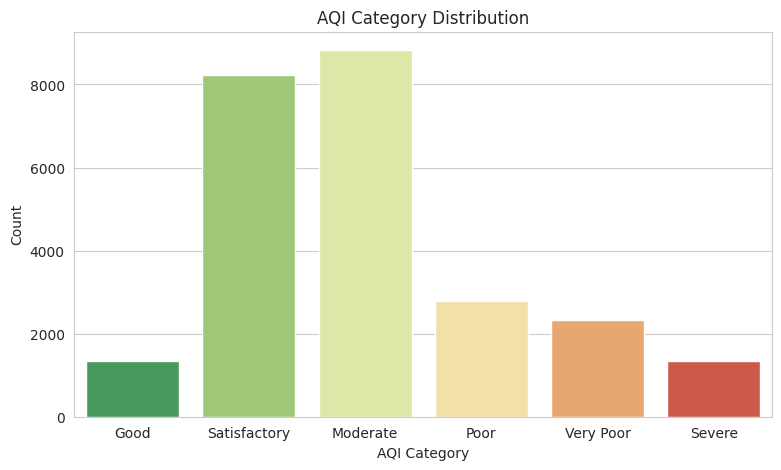

AQI Category counts:
AQI_Bucket
Good            1341
Satisfactory    8224
Moderate        8829
Poor            2781
Very Poor       2337
Severe          1338
Name: count, dtype: int64


In [11]:
# =========================================================
# AQI CATEGORY DISTRIBUTION
# =========================================================

# Define correct CPCB order for readability
bucket_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

plt.figure(figsize=(9, 5))
sns.countplot(data=df_eda, x='AQI_Bucket', order=bucket_order, palette='RdYlGn_r')
plt.title('AQI Category Distribution')
plt.xlabel('AQI Category')
plt.ylabel('Count')
plt.show()

print("AQI Category counts:")
print(df_eda['AQI_Bucket'].value_counts().reindex(bucket_order))

### Interpretation â€” AQI Distribution

- The AQI distribution is **right-skewed**: median (118) is noticeably lower
  than the mean (166.46), with a long tail toward high values (max = 2049).
  This confirms that while most days have moderate air quality, a
  significant number of days experience very high pollution.
- **Category breakdown**: "Moderate" (8,829) and "Satisfactory" (8,224) are
  the two most frequent categories, together making up ~68% of all recorded
  days. "Severe" days (1,338) and "Very Poor" days (2,337) together account
  for ~14.8% of records â€” a non-trivial share of dangerously polluted days.
- Only 1,341 days (~5.4%) fall in the "Good" category, indicating that
  clean-air days are relatively rare across the cities and period covered
  by this dataset.

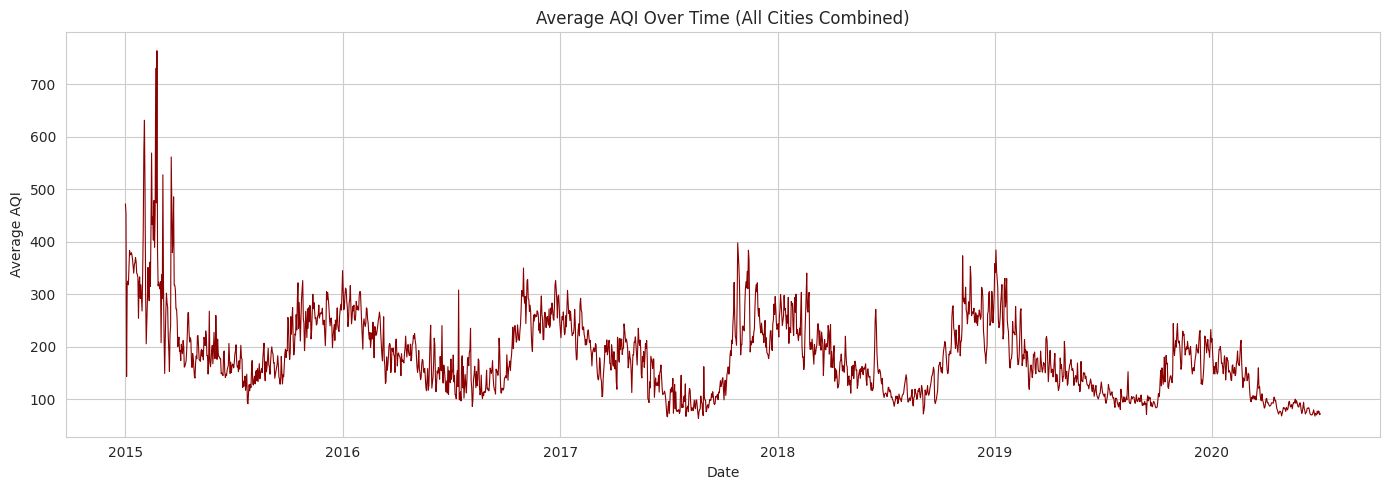

In [12]:
# =========================================================
# AQI TREND OVER TIME (OVERALL, DAILY MEAN ACROSS CITIES)
# =========================================================

daily_avg_aqi = df_eda.groupby('Date')['AQI'].mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_avg_aqi.index, daily_avg_aqi.values, color='darkred', linewidth=0.8)
plt.title('Average AQI Over Time (All Cities Combined)')
plt.xlabel('Date')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.show()

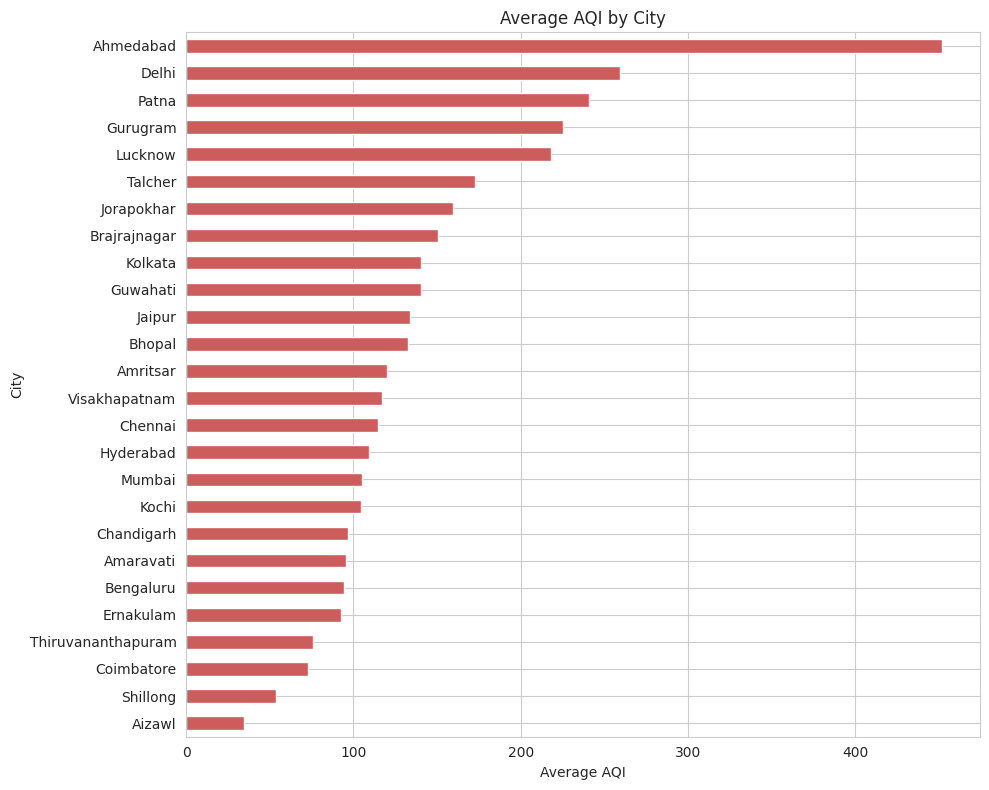

Top 5 cities by average AQI:
City
Ahmedabad    452.122939
Delhi        259.487744
Patna        240.782042
Gurugram     225.123882
Lucknow      217.973059
Name: AQI, dtype: float64

Bottom 5 cities by average AQI:
City
Ernakulam             92.359477
Thiruvananthapuram    75.878327
Coimbatore            73.023256
Shillong              53.795122
Aizawl                34.765766
Name: AQI, dtype: float64


In [13]:
# =========================================================
# CITY-LEVEL AQI COMPARISON
# =========================================================

city_avg_aqi = df_eda.groupby('City')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
city_avg_aqi.plot(kind='barh', color='indianred')
plt.title('Average AQI by City')
plt.xlabel('Average AQI')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 cities by average AQI:")
print(city_avg_aqi.head())
print("\nBottom 5 cities by average AQI:")
print(city_avg_aqi.tail())

### Interpretation â€” City-Level AQI Comparison

- **Ahmedabad has by far the highest average AQI (452.12)** â€” substantially
  higher than every other city, and nearly double the second-highest city
  (Delhi at 259.49). This is a striking outlier worth flagging for further
  investigation (e.g., checking whether Ahmedabad's readings are
  concentrated in a specific date range, or reflect a genuinely different
  pollution profile).
- **Delhi (259.49), Patna (240.78), Gurugram (225.12), and Lucknow (217.97)**
  round out the top 5 â€” all North Indian cities, consistent with widely
  reported pollution patterns in the Indo-Gangetic plain region.
- **The cleanest cities are in the South/Northeast**: Aizawl (34.77),
  Shillong (53.80), Coimbatore (73.02), Thiruvananthapuram (75.88), and
  Ernakulam (92.36) have the lowest average AQI, all located in South India
  or the Northeast.
- This suggests a **strong regional/geographic pattern** in air quality
  across India, though this dataset alone cannot establish the underlying
  causes (e.g., industrial density, geography, meteorology).

Ahmedabad AQI stats:
count    1334.000000
mean      452.122939
std       311.729553
min        48.000000
25%       231.000000
50%       384.500000
75%       542.750000
max      2049.000000
Name: AQI, dtype: float64

Ahmedabad date range: 2015-01-29 00:00:00 to 2020-07-01 00:00:00


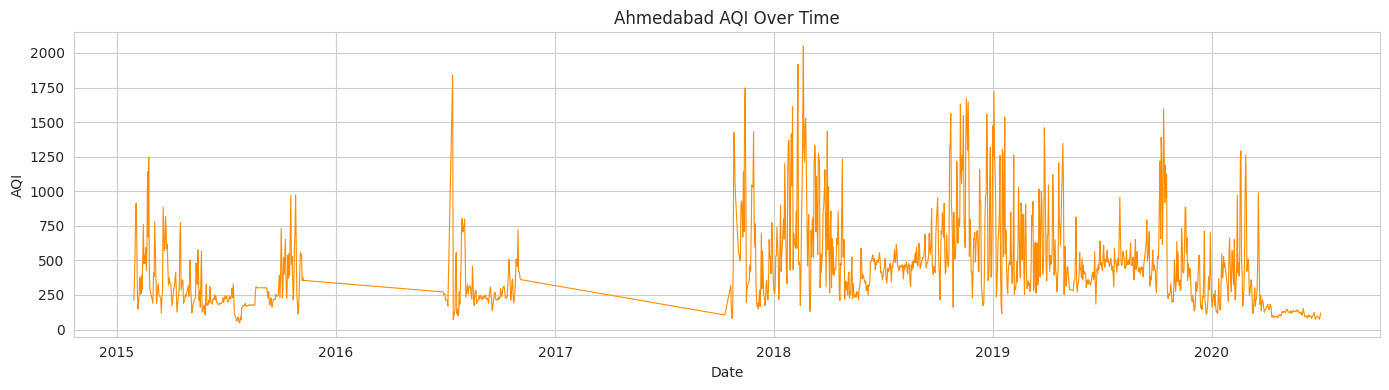

In [14]:
# =========================================================
# INVESTIGATE AHMEDABAD'S HIGH AQI
# =========================================================

ahmedabad = df_eda[df_eda['City'] == 'Ahmedabad']

print("Ahmedabad AQI stats:")
print(ahmedabad['AQI'].describe())

print("\nAhmedabad date range:", ahmedabad['Date'].min(), "to", ahmedabad['Date'].max())

# AQI over time just for Ahmedabad
plt.figure(figsize=(14, 4))
plt.plot(ahmedabad['Date'], ahmedabad['AQI'], color='darkorange', linewidth=0.8)
plt.title('Ahmedabad AQI Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

In [15]:
# =========================================================
# CHECK FOR MISSING/GAP PERIODS IN AHMEDABAD'S AQI DATA
# =========================================================

# Reindex Ahmedabad's data to a full daily date range and check for gaps
ahmedabad_full_range = pd.date_range(
    start=ahmedabad['Date'].min(),
    end=ahmedabad['Date'].max(),
    freq='D'
)

ahmedabad_indexed = ahmedabad.set_index('Date').reindex(ahmedabad_full_range)

print("Total expected days:", len(ahmedabad_full_range))
print("Days with actual AQI value:", ahmedabad_indexed['AQI'].notnull().sum())
print("Days with missing AQI:", ahmedabad_indexed['AQI'].isnull().sum())

# Find the longest gaps (consecutive missing AQI stretches)
is_null = ahmedabad_indexed['AQI'].isnull()
gap_groups = (is_null != is_null.shift()).cumsum()
gap_sizes = is_null.groupby(gap_groups).sum()
gap_sizes = gap_sizes[gap_sizes > 0].sort_values(ascending=False)

print("\nTop 10 longest consecutive missing-AQI gaps (in days):")
print(gap_sizes.head(10))

Total expected days: 1981
Days with actual AQI value: 1334
Days with missing AQI: 647

Top 10 longest consecutive missing-AQI gaps (in days):
AQI
40    340
30    232
42      9
32      7
56      5
2       4
44      4
64      4
52      3
54      3
Name: AQI, dtype: int64


### Interpretation â€” Data Gap Artifact

Investigation revealed that Ahmedabad's AQI data contains large gaps â€”
notably a 340-day and a 232-day period with no AQI readings. When plotted
naively (connecting only the available data points), matplotlib draws a
straight diagonal line across these gaps, creating a **false visual
impression of a gradual, smooth AQI trend**. In reality, no data exists for
these periods.

This is corrected below by reindexing the series to a full daily date range
and preserving missing values as actual gaps (breaks) in the line, rather
than connecting across them. This is an important data quality limitation:
several cities may have extended periods of missing AQI, which affects both
visualization and forecasting reliability for those periods.

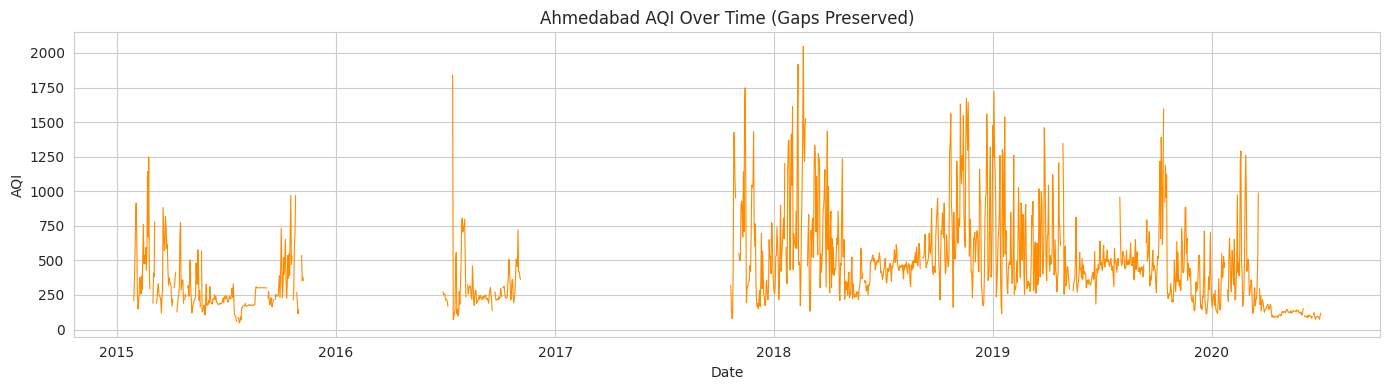

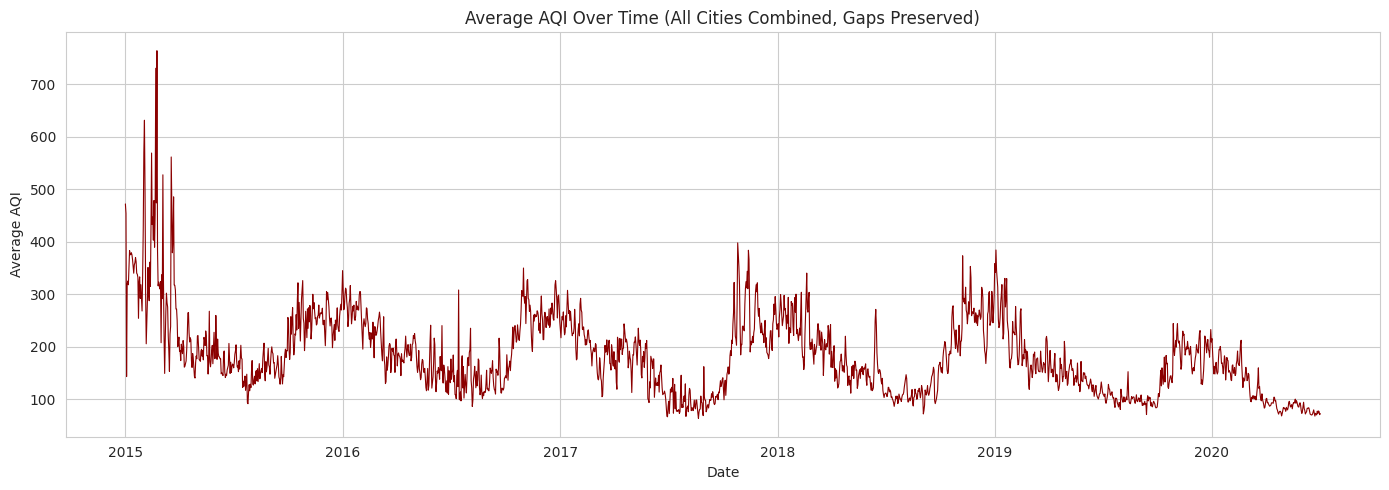

Total days in range: 2009
Days with at least one city's AQI value: 2009
Days with NO AQI data across all cities: 0


In [16]:
# =========================================================
# CORRECTED TIME-SERIES PLOTS (GAPS PRESERVED, NOT CONNECTED)
# =========================================================

# --- Ahmedabad corrected plot ---
plt.figure(figsize=(14, 4))
plt.plot(ahmedabad_indexed.index, ahmedabad_indexed['AQI'], color='darkorange', linewidth=0.8)
plt.title('Ahmedabad AQI Over Time (Gaps Preserved)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

# --- Overall average AQI corrected plot ---
# Reindex to full date range at the overall level too
full_range = pd.date_range(start=df_eda['Date'].min(), end=df_eda['Date'].max(), freq='D')
daily_avg_full = daily_avg_aqi.reindex(full_range)

plt.figure(figsize=(14, 5))
plt.plot(daily_avg_full.index, daily_avg_full.values, color='darkred', linewidth=0.8)
plt.title('Average AQI Over Time (All Cities Combined, Gaps Preserved)')
plt.xlabel('Date')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.show()

# Check how many dates have zero contributing cities in the overall average
print("Total days in range:", len(full_range))
print("Days with at least one city's AQI value:", daily_avg_full.notnull().sum())
print("Days with NO AQI data across all cities:", daily_avg_full.isnull().sum())

### Interpretation â€” AQI Time Trends

- After correcting the plot to preserve genuine data gaps (rather than
  connecting across missing periods), Ahmedabad's plot confirms two extended
  real gaps in its AQI data (~mid-2016 and ~2017), consistent with the
  340-day and 232-day gap findings.
- The **overall average AQI time series (all cities combined) shows a
  clear recurring annual seasonal pattern**: AQI rises toward peaks around
  **Decemberâ€“January** each year and declines to lows around
  **Juneâ€“September**. This pattern repeats consistently across all five
  years in the dataset (2015â€“2019), suggesting a genuine seasonal cycle
  rather than random noise.
- This is consistent with known factors in North Indian air quality (e.g.,
  winter temperature inversions trapping pollutants, reduced wind
  dispersion, and increased biomass/crop burning in winter months), though
  this dataset alone does not measure meteorological causes directly.

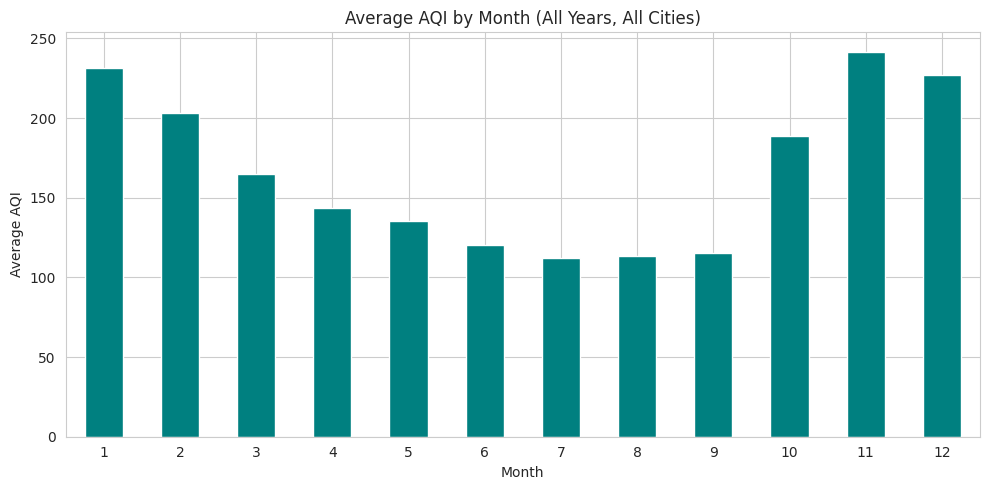

Average AQI by month:
Month
1     231.674918
2     202.905197
3     164.735281
4     143.355120
5     135.489579
6     120.198379
7     111.854575
8     113.613176
9     115.191804
10    188.613552
11    241.681302
12    227.084980
Name: AQI, dtype: float64

Average AQI by season:
Season
Winter          220.610764
Post-Monsoon    215.473464
Summer          147.670392
Monsoon         115.555426
Name: AQI, dtype: float64


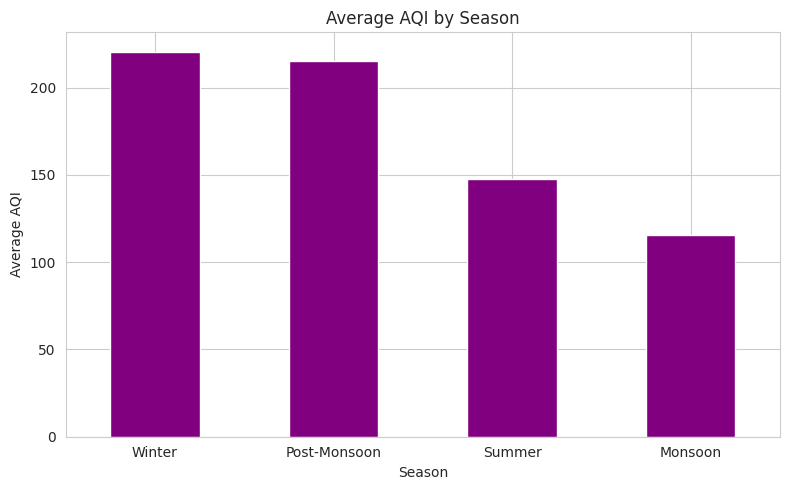

In [17]:
# =========================================================
# MONTHLY AND SEASONAL AQI PATTERNS
# =========================================================

df_eda['Month'] = df_eda['Date'].dt.month
df_eda['Year'] = df_eda['Date'].dt.year

# Monthly average AQI (across all years/cities)
monthly_avg = df_eda.groupby('Month')['AQI'].mean()

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar', color='teal')
plt.title('Average AQI by Month (All Years, All Cities)')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Average AQI by month:")
print(monthly_avg)

# Define season mapping for India
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df_eda['Season'] = df_eda['Month'].apply(get_season)

season_avg = df_eda.groupby('Season')['AQI'].mean().sort_values(ascending=False)
print("\nAverage AQI by season:")
print(season_avg)

plt.figure(figsize=(8, 5))
season_avg.plot(kind='bar', color='purple')
plt.title('Average AQI by Season')
plt.xlabel('Season')
plt.ylabel('Average AQI')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation â€” Seasonal AQI Patterns

- **November (241.68) and January (231.67)** have the highest average AQI,
  followed closely by December (227.08) and February (202.91) â€” confirming
  a strong winter pollution peak.
- **July (111.85) and August (113.61)** have the lowest average AQI,
  coinciding with the monsoon season, when rainfall likely aids pollutant
  dispersion/settling.
- At the seasonal level: **Winter (220.61) and Post-Monsoon (215.47)** have
  nearly double the average AQI of **Monsoon (115.56)**, with Summer
  (147.67) in between.
- This is a clear, consistent, and quantifiable seasonal cycle across the
  dataset, and will be directly useful as a feature (month/season) in the
  AQI forecasting model.

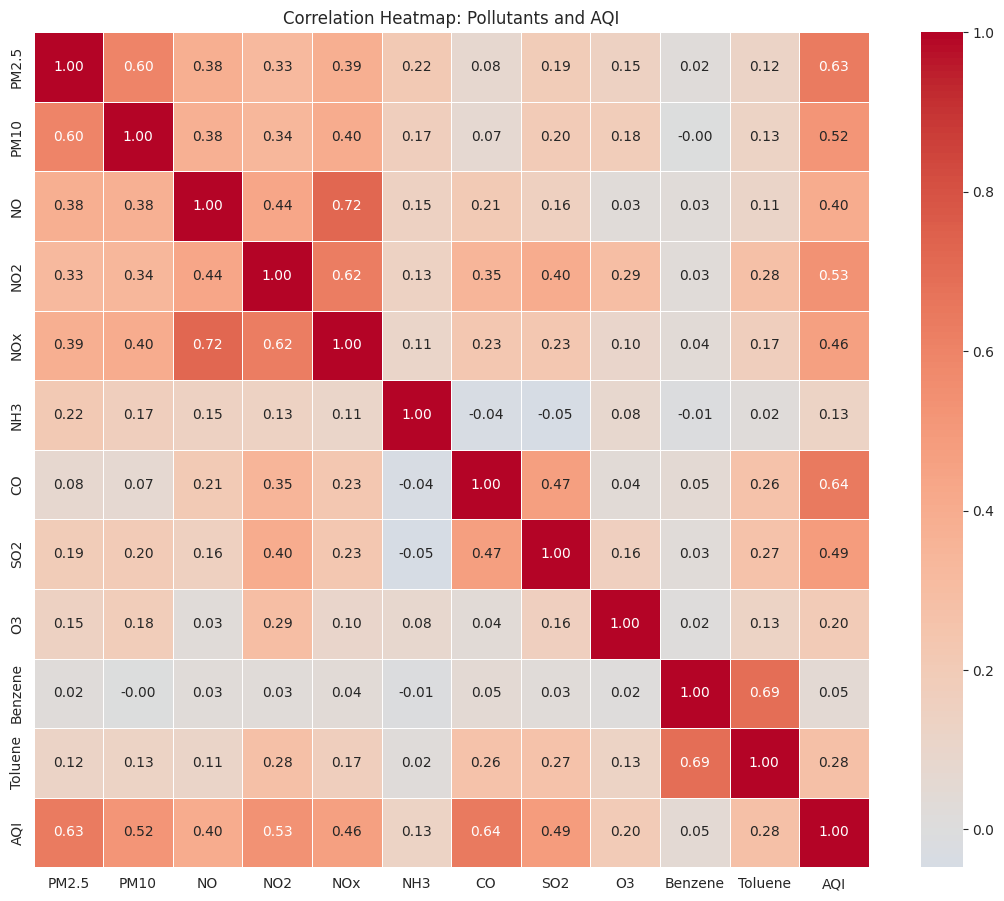

Correlation of each pollutant with AQI (sorted):
AQI        1.000000
CO         0.640062
PM2.5      0.634594
NO2        0.531250
PM10       0.518701
SO2        0.485372
NOx        0.463276
NO         0.398618
Toluene    0.279890
O3         0.199387
NH3        0.131925
Benzene    0.050794
Name: AQI, dtype: float64


In [18]:
# =========================================================
# POLLUTANT CORRELATION HEATMAP
# =========================================================

pollutant_and_aqi_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
                           'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']

corr_matrix = df_eda[pollutant_and_aqi_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap: Pollutants and AQI')
plt.tight_layout()
plt.show()

print("Correlation of each pollutant with AQI (sorted):")
print(corr_matrix['AQI'].sort_values(ascending=False))

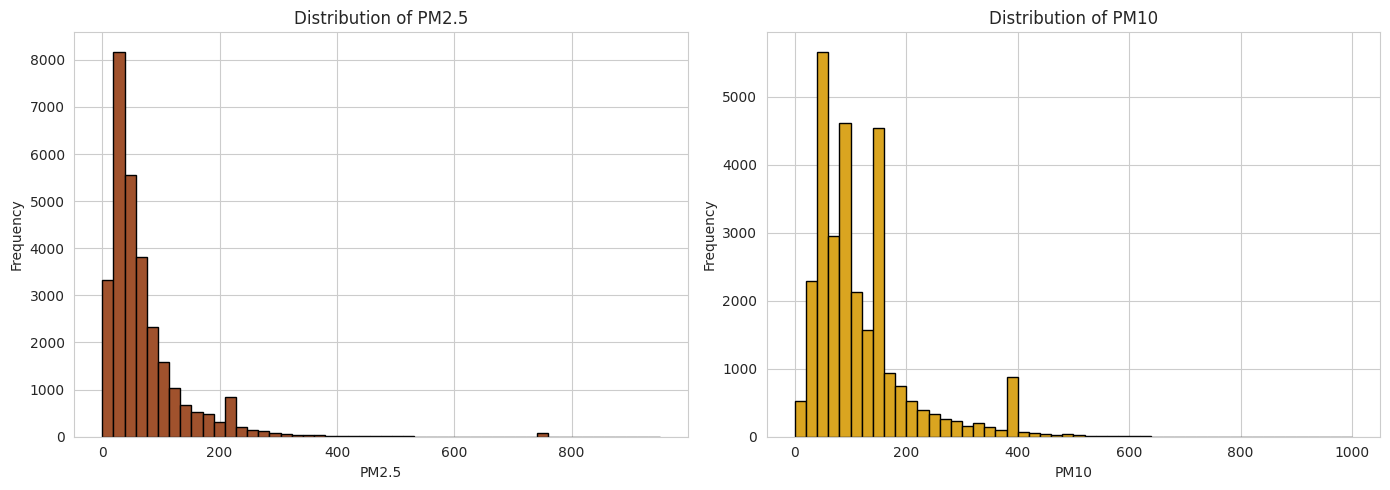

PM2.5 stats:
count    29531.000000
mean        71.042188
std         74.679338
min          0.040000
25%         26.750000
50%         48.050000
75%         84.868441
max        949.990000
Name: PM2.5, dtype: float64

PM10 stats:
count    29531.000000
mean       120.475568
std         90.655176
min          0.010000
25%         58.530000
50%         97.820000
75%        152.410130
max       1000.000000
Name: PM10, dtype: float64


In [19]:
# =========================================================
# PM2.5 AND PM10 DISTRIBUTIONS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['PM2.5'].dropna(), bins=50, color='sienna', edgecolor='black')
axes[0].set_title('Distribution of PM2.5')
axes[0].set_xlabel('PM2.5')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_clean['PM10'].dropna(), bins=50, color='goldenrod', edgecolor='black')
axes[1].set_title('Distribution of PM10')
axes[1].set_xlabel('PM10')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("PM2.5 stats:")
print(df_clean['PM2.5'].describe())
print("\nPM10 stats:")
print(df_clean['PM10'].describe())

In [20]:
# =========================================================
# VERIFY PM10 SPIKE ARTIFACT (LUCKNOW GLOBAL MEDIAN FILL)
# =========================================================

# Check what value was used for Lucknow's PM10 fill
lucknow_pm10 = df_clean[df_clean['City'] == 'Lucknow']['PM10']
print("Lucknow PM10 unique values (first 10):", lucknow_pm10.unique()[:10])
print("Lucknow PM10 value counts:")
print(lucknow_pm10.value_counts().head())

# Confirm this matches the spike location seen in the histogram
print("\nGlobal PM10 median used for fallback:", df_eda['PM10'].median())

Lucknow PM10 unique values (first 10): [97.82]
Lucknow PM10 value counts:
PM10
97.82    2009
Name: count, dtype: int64

Global PM10 median used for fallback: 97.82


In [21]:
# =========================================================
# INVESTIGATE PM10 SPIKE AROUND 380-400
# =========================================================

# Isolate values in the suspicious range
spike_range = df_clean[(df_clean['PM10'] >= 370) & (df_clean['PM10'] <= 410)]

print("Number of rows in PM10 range 370-410:", spike_range.shape[0])
print("\nMost frequent exact PM10 values in this range:")
print(spike_range['PM10'].value_counts().head(10))

print("\nCities contributing to this spike:")
print(spike_range['City'].value_counts())

Number of rows in PM10 range 370-410: 953

Most frequent exact PM10 values in this range:
PM10
395.40    766
386.66      2
377.61      2
398.16      2
386.16      2
371.05      1
393.20      1
387.65      1
393.70      1
394.97      1
Name: count, dtype: int64

Cities contributing to this spike:
City
Gurugram      788
Delhi         101
Talcher        36
Jorapokhar     15
Kolkata        11
Amritsar        2
Name: count, dtype: int64


In [22]:
# =========================================================
# CONFIRM GURUGRAM PM10 MEDIAN FILL
# =========================================================

# Check original (pre-cleaning) missing count for Gurugram's PM10
gurugram_original = df[df['City'] == 'Gurugram']
print("Gurugram total rows:", gurugram_original.shape[0])
print("Gurugram original missing PM10:", gurugram_original['PM10'].isnull().sum())

# Check the actual median value used
gurugram_clean = df_clean[df_clean['City'] == 'Gurugram']
print("\nGurugram PM10 median (post-cleaning, non-imputed values check):")
print("Value 395.40 count in Gurugram:", (gurugram_clean['PM10'] == 395.40).sum())
print("Gurugram PM10 stats after cleaning:")
print(gurugram_clean['PM10'].describe())

Gurugram total rows: 1679
Gurugram original missing PM10: 939

Gurugram PM10 median (post-cleaning, non-imputed values check):
Value 395.40 count in Gurugram: 766
Gurugram PM10 stats after cleaning:
count    1679.000000
mean      285.194458
std       124.691218
min        10.000000
25%       171.219609
50%       342.330000
75%       395.400000
max       666.720000
Name: PM10, dtype: float64


### Interpretation â€” Pollutant Correlations & Distributions

- **Correlation with AQI**: CO (0.64) and PM2.5 (0.63) show the strongest
  positive correlation with AQI, followed by NO2 (0.53), PM10 (0.52), and
  SO2 (0.49). NH3 (0.13) and Benzene (0.05) show very weak correlation with
  AQI in this dataset.
- **Multicollinearity observed**: NO and NOx are highly correlated (0.72),
  as are NO2 and NOx (0.62), and Benzene and Toluene (0.69) â€” expected,
  since these pollutants often originate from similar combustion sources
  (vehicular/industrial emissions).
- **PM2.5 distribution** is heavily right-skewed, with most values
  concentrated below 150 and a long tail extending to ~950 â€” consistent
  with occasional severe pollution episodes.
- **PM10 distribution shows an artificial spike around 395.4.** Investigation
  traced this to **Gurugram**, which had 939 of its 1,679 PM10 readings
  (56%) originally missing. After time-based interpolation, 766 remaining
  gaps were filled with Gurugram's own per-city median (395.40), creating a
  repeated-value spike in the aggregate distribution. This is a known,
  documented **imputation artifact** rather than a genuine pollution
  pattern, and is noted as a limitation of the median-fallback

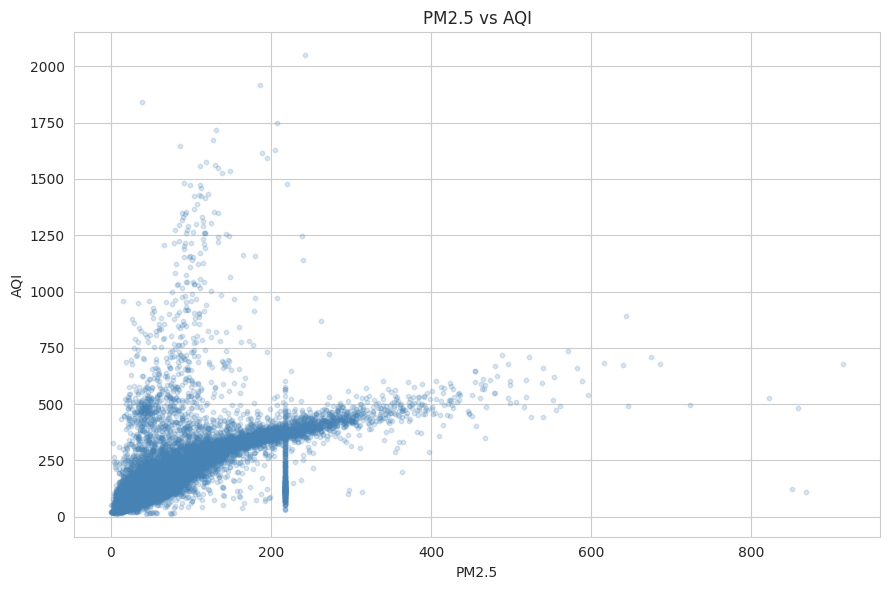

Correlation between PM2.5 and AQI: 0.635


In [23]:
# =========================================================
# PM2.5 vs AQI RELATIONSHIP
# =========================================================

plt.figure(figsize=(9, 6))
plt.scatter(df_eda['PM2.5'], df_eda['AQI'], alpha=0.2, s=10, color='steelblue')
plt.title('PM2.5 vs AQI')
plt.xlabel('PM2.5')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

print("Correlation between PM2.5 and AQI:", df_eda['PM2.5'].corr(df_eda['AQI']).round(3))

### Interpretation â€” PM2.5 vs AQI

- There is a clear **positive relationship** between PM2.5 and AQI
  (correlation = 0.635), consistent with PM2.5 being one of the primary
  pollutants used in AQI sub-index calculation by CPCB.
- The relationship shows **diminishing sensitivity at higher PM2.5 levels**
  â€” AQI increases steeply at low-to-moderate PM2.5 values but the spread
  widens considerably at higher PM2.5, indicating other pollutants also
  substantially influence AQI at high pollution levels.
- A faint vertical clustering of points is visible around PM2.5 â‰ˆ 220,
  consistent with the same type of median-imputation artifact identified
  earlier for PM10 in Gurugram. This reinforces that **some straight-line/
  vertical patterns in this dataset stem from imputation for cities with
  high missingness, not genuine pollutant behavior** â€” a limitation
  documented for this

## 10. Time-Series Feature Engineering

We now prepare the dataset for **next-day AQI forecasting**. This requires
careful handling to avoid **temporal leakage**:

1. Data must be sorted by `City` and `Date`.
2. Lag features (previous day's/days' values) and rolling statistics must be
   computed **separately per city** â€” a lag feature must never pull data
   from a different city's timeline.
3. The target variable will be **next day's AQI** (`AQI` shifted by -1
   within each city group).
4. Only rows with valid AQI (both current and lag/target) will be used in
   the final modeling dataset.

We will create:
- Lag features: `AQI_lag_1`, `AQI_lag_3`, `AQI_lag_7`
- Lag features for key pollutants: `PM2.5_lag_1`, `PM10_lag_1`, `NO2_lag_1`
- Rolling averages: `AQI_roll_mean_3`, `AQI_roll_mean_7`
- Calendar features: `Month`, `Day of week`, `Season`

In [24]:
# =========================================================
# PREPARE BASE DATASET FOR FEATURE ENGINEERING
# =========================================================

# Start from the fully cleaned pollutant data (df_clean has 0 missing pollutants)
# We keep AQI as-is (with its real missing values) since it's our target source
df_fe = df_clean.copy()

# Ensure sorted by City then Date (critical for lag/rolling correctness)
df_fe = df_fe.sort_values(['City', 'Date']).reset_index(drop=True)

print("Shape before feature engineering:", df_fe.shape)
print("Cities:", df_fe['City'].nunique())
print("Date range:", df_fe['Date'].min(), "to", df_fe['Date'].max())

df_fe.head()

Shape before feature engineering: (29531, 15)
Cities: 26
Date range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00


,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
0,2015-01-01,Ahmedabad,73.24,141.54,0.92,18.22,17.15,16.54,0.92,27.64,133.36,0.00,0.02,NaN,NaN
1,2015-01-02,Ahmedabad,73.24,141.54,0.97,15.69,16.46,16.54,0.97,24.55,34.06,3.68,5.50,NaN,NaN
2,2015-01-03,Ahmedabad,73.24,141.54,17.40,19.30,29.70,16.54,17.40,29.07,30.70,6.80,16.40,NaN,NaN
3,2015-01-04,Ahmedabad,73.24,141.54,1.70,18.48,17.97,16.54,1.70,18.59,36.08,4.43,10.14,NaN,NaN
4,2015-01-05,Ahmedabad,73.24,141.54,22.10,21.42,37.76,16.54,22.10,39.33,39.31,7.01,18.89,NaN,NaN


In [25]:
# =========================================================
# CREATE LAG AND ROLLING FEATURES (PER CITY, LEAKAGE-SAFE)
# =========================================================

def create_time_features(group):
    group = group.sort_values('Date').copy()

    # --- AQI lag features ---
    group['AQI_lag_1'] = group['AQI'].shift(1)
    group['AQI_lag_3'] = group['AQI'].shift(3)
    group['AQI_lag_7'] = group['AQI'].shift(7)

    # --- Key pollutant lag features (lag 1) ---
    group['PM2.5_lag_1'] = group['PM2.5'].shift(1)
    group['PM10_lag_1'] = group['PM10'].shift(1)
    group['NO2_lag_1'] = group['NO2'].shift(1)
    group['CO_lag_1'] = group['CO'].shift(1)

    # --- Rolling averages (using only past values, shifted before rolling) ---
    # shift(1) first ensures the rolling window does NOT include the current row
    group['AQI_roll_mean_3'] = group['AQI'].shift(1).rolling(window=3).mean()
    group['AQI_roll_mean_7'] = group['AQI'].shift(1).rolling(window=7).mean()
    group['PM2.5_roll_mean_3'] = group['PM2.5'].shift(1).rolling(window=3).mean()

    return group

df_fe = df_fe.groupby('City', group_keys=False).apply(create_time_features)

print("Shape after lag/rolling feature creation:", df_fe.shape)
df_fe[['City', 'Date', 'AQI', 'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_7',
       'AQI_roll_mean_3', 'AQI_roll_mean_7']].head(10)

Shape after lag/rolling feature creation: (29531, 25)


,City,Date,AQI,AQI_lag_1,AQI_lag_3,AQI_lag_7,AQI_roll_mean_3,AQI_roll_mean_7
0,Ahmedabad,2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,NaN,NaN,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,NaN,NaN,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,NaN,NaN,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,NaN,NaN,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,NaN,NaN,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,NaN,NaN,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,NaN,NaN,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# =========================================================
# CALENDAR FEATURES AND TARGET VARIABLE (NEXT-DAY AQI)
# =========================================================

# --- Calendar features ---
df_fe['Month'] = df_fe['Date'].dt.month
df_fe['DayOfWeek'] = df_fe['Date'].dt.dayofweek  # 0=Monday, 6=Sunday

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df_fe['Season'] = df_fe['Month'].apply(get_season)

# One-hot encode Season (simple, interpretable for tree models too)
df_fe = pd.get_dummies(df_fe, columns=['Season'], prefix='Season')

# --- Target variable: NEXT DAY'S AQI, per city ---
def create_target(group):
    group = group.sort_values('Date').copy()
    group['AQI_target_next_day'] = group['AQI'].shift(-1)
    return group

df_fe = df_fe.groupby('City', group_keys=False).apply(create_target)

print("Shape after calendar features + target creation:", df_fe.shape)
print("\nColumns:", df_fe.columns.tolist())

df_fe[['City', 'Date', 'AQI', 'AQI_target_next_day', 'Month', 'DayOfWeek']].head(10)

Shape after calendar features + target creation: (29531, 32)

Columns: ['Date', 'City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket', 'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_7', 'PM2.5_lag_1', 'PM10_lag_1', 'NO2_lag_1', 'CO_lag_1', 'AQI_roll_mean_3', 'AQI_roll_mean_7', 'PM2.5_roll_mean_3', 'Month', 'DayOfWeek', 'Season_Monsoon', 'Season_Post-Monsoon', 'Season_Summer', 'Season_Winter', 'AQI_target_next_day']


,City,Date,AQI,AQI_target_next_day,Month,DayOfWeek
0,Ahmedabad,2015-01-01,NaN,NaN,1,3
1,Ahmedabad,2015-01-02,NaN,NaN,1,4
2,Ahmedabad,2015-01-03,NaN,NaN,1,5
3,Ahmedabad,2015-01-04,NaN,NaN,1,6
4,Ahmedabad,2015-01-05,NaN,NaN,1,0
5,Ahmedabad,2015-01-06,NaN,NaN,1,1
6,Ahmedabad,2015-01-07,NaN,NaN,1,2
7,Ahmedabad,2015-01-08,NaN,NaN,1,3
8,Ahmedabad,2015-01-09,NaN,NaN,1,4
9,Ahmedabad,2015-01-10,NaN,NaN,1,5


## 11. Final Modeling Dataset & Chronological Train/Test Split

We now finalize the modeling dataset:

1. Drop rows where the **target** (`AQI_target_next_day`) is missing â€”
   these rows cannot be used for supervised learning.
2. Drop rows where **any lag/rolling feature** is missing â€” these occur at
   the start of each city's series or where raw AQI itself was missing
   (since lags derive from AQI).
3. Split the data **chronologically** (not randomly) â€” training on earlier
   dates, testing on later dates â€” to simulate real-world forecasting and
   avoid temporal leakage.

We use a global date cutoff so that the test set represents genuinely
"future" data relative to the training set, across all cities.

In [27]:
# =========================================================
# BUILD FINAL MODELING DATASET
# =========================================================

# Define feature columns for modeling
feature_cols = [
    'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_7',
    'PM2.5_lag_1', 'PM10_lag_1', 'NO2_lag_1', 'CO_lag_1',
    'AQI_roll_mean_3', 'AQI_roll_mean_7', 'PM2.5_roll_mean_3',
    'Month', 'DayOfWeek',
    'Season_Monsoon', 'Season_Post-Monsoon', 'Season_Summer', 'Season_Winter'
]

target_col = 'AQI_target_next_day'

required_cols = feature_cols + [target_col]

# Drop rows with any missing value in features or target
df_model = df_fe.dropna(subset=required_cols).copy()

print("Shape of final modeling dataset:", df_model.shape)
print("\nDate range in modeling dataset:", df_model['Date'].min(), "to", df_model['Date'].max())
print("Cities represented:", df_model['City'].nunique())

print("\nRows per city in modeling dataset:")
print(df_model['City'].value_counts())

Shape of final modeling dataset: (21841, 32)

Date range in modeling dataset: 2015-01-08 00:00:00 to 2020-06-30 00:00:00
Cities represented: 26

Rows per city in modeling dataset:
City
Delhi                 1960
Bengaluru             1848
Lucknow               1812
Chennai               1807
Hyderabad             1801
Patna                 1187
Gurugram              1152
Ahmedabad             1097
Jaipur                1043
Thiruvananthapuram     968
Amritsar               919
Visakhapatnam          886
Kolkata                739
Mumbai                 731
Amaravati              647
Jorapokhar             566
Brajrajnagar           514
Guwahati               457
Talcher                453
Chandigarh             272
Bhopal                 262
Coimbatore             214
Shillong               153
Kochi                  135
Ernakulam              122
Aizawl                  96
Name: count, dtype: int64


In [28]:
# =========================================================
# CHRONOLOGICAL TRAIN/TEST SPLIT
# =========================================================

# Sort by date to ensure proper chronological ordering
df_model = df_model.sort_values('Date').reset_index(drop=True)

# Use an 80/20 chronological split based on date
split_date = df_model['Date'].quantile(0.8, interpolation='nearest')

print("Chronological split date:", split_date)

train_df = df_model[df_model['Date'] <= split_date].copy()
test_df = df_model[df_model['Date'] > split_date].copy()

print("\nTraining set shape:", train_df.shape)
print("Training date range:", train_df['Date'].min(), "to", train_df['Date'].max())

print("\nTest set shape:", test_df.shape)
print("Test date range:", test_df['Date'].min(), "to", test_df['Date'].max())

# Prepare X, y for modeling
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Chronological split date: 2019-12-14 00:00:00

Training set shape: (17487, 32)
Training date range: 2015-01-08 00:00:00 to 2019-12-14 00:00:00

Test set shape: (4354, 32)
Test date range: 2019-12-15 00:00:00 to 2020-06-30 00:00:00

X_train shape: (17487, 16)
X_test shape: (4354, 16)


## 12. Baseline Model â€” Linear Regression

We start with a simple Linear Regression model as our baseline. This gives
us a reference point to evaluate whether more complex models (Random
Forest, XGBoost) provide meaningful improvement.

Note: The test period (Dec 2019 â€“ June 2020) includes the COVID-19
lockdown period in India (beginning ~March 25, 2020), which caused a sharp,
historically unprecedented drop in pollution levels due to reduced
industrial and vehicular activity. Since no comparable period exists in the
training data, this may affect model performance during that window â€” this
will be examined in the Error Analysis section.

In [29]:
# =========================================================
# BASELINE MODEL - LINEAR REGRESSION
# =========================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

# Evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"MAE:  {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"RÂ²:   {r2_lr:.4f}")

Linear Regression Performance:
MAE:  27.24
RMSE: 50.68
RÂ²:   0.6715


## 13. Random Forest Regressor

Random Forest is used as our main model â€” an ensemble of decision trees
that can capture non-linear relationships and interactions between
pollutant lag features, which a linear model cannot.

In [30]:
# =========================================================
# RANDOM FOREST REGRESSOR
# =========================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE:  {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"RÂ²:   {r2_rf:.4f}")

Random Forest Performance:
MAE:  27.20
RMSE: 49.96
RÂ²:   0.6808


## 14. XGBoost Regressor

XGBoost is used as our strongest model â€” a gradient-boosted tree ensemble
known for strong performance on structured/tabular data, often outperforming
Random Forest by correcting errors iteratively across boosting rounds.

In [31]:
# =========================================================
# XGBOOST REGRESSOR
# =========================================================

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

# Evaluation metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print(f"MAE:  {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"RÂ²:   {r2_xgb:.4f}")

XGBoost Performance:
MAE:  27.87
RMSE: 50.32
RÂ²:   0.6761


In [32]:
# =========================================================
# MODEL COMPARISON TABLE
# =========================================================

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression (Baseline)', 'Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_rf, mae_xgb],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R2': [r2_lr, r2_rf, r2_xgb]
})

comparison_df = comparison_df.round(3)
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Model']
print(f"\nBest performing model (by RMSE): {best_model_name}")

                       Model    MAE   RMSE    R2
Linear Regression (Baseline) 27.241 50.683 0.671
               Random Forest 27.199 49.962 0.681
                     XGBoost 27.867 50.322 0.676

Best performing model (by RMSE): Random Forest


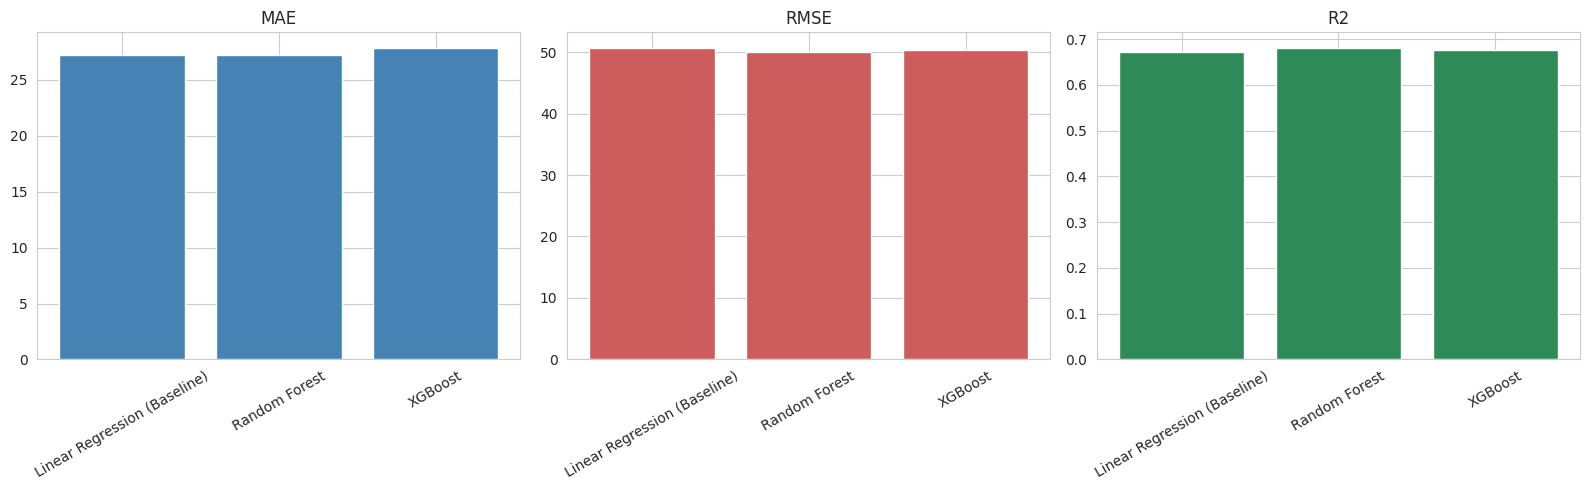

In [33]:
# =========================================================
# VISUAL MODEL COMPARISON
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['MAE', 'RMSE', 'R2']
colors = ['steelblue', 'indianred', 'seagreen']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(comparison_df['Model'], comparison_df[metric], color=color)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Interpretation â€” Model Comparison

All three models achieve very similar performance:

| Model | MAE | RMSE | RÂ² |
|---|---|---|---|
| Linear Regression (Baseline) | 27.24 | 50.68 | 0.671 |
| Random Forest | 27.20 | 49.96 | 0.681 |
| XGBoost | 27.87 | 50.32 | 0.676 |

**Random Forest achieves the best RMSE (49.96) and RÂ² (0.681)**, narrowly
outperforming both the linear baseline and XGBoost, and is selected as the
final model for subsequent analysis (Actual vs Predicted visualization,
error analysis, and SHAP explainability).

The fact that all three models perform comparably â€” including the simple
linear baseline â€” suggests that the engineered lag and rolling-average
features (particularly `AQI_lag_1` and `AQI_roll_mean_3/7`) capture most of
the predictable day-to-day persistence in AQI, and that the relationship
between recent AQI history and next-day AQI is largely close to linear.
Additional model complexity (Random Forest, XGBoost) yields only marginal
improvement, indicating diminishing returns from non-linear modeling on this
feature set. The remaining unexplained variance (~32%, RÂ² â‰ˆ 0.68) likely
reflects genuine short-term volatility driven by factors not present in this
dataset, such as meteorological conditions (wind speed, rainfall,
temperature inversions) and localized events.

**Selected model for further analysis: Random Forest.**

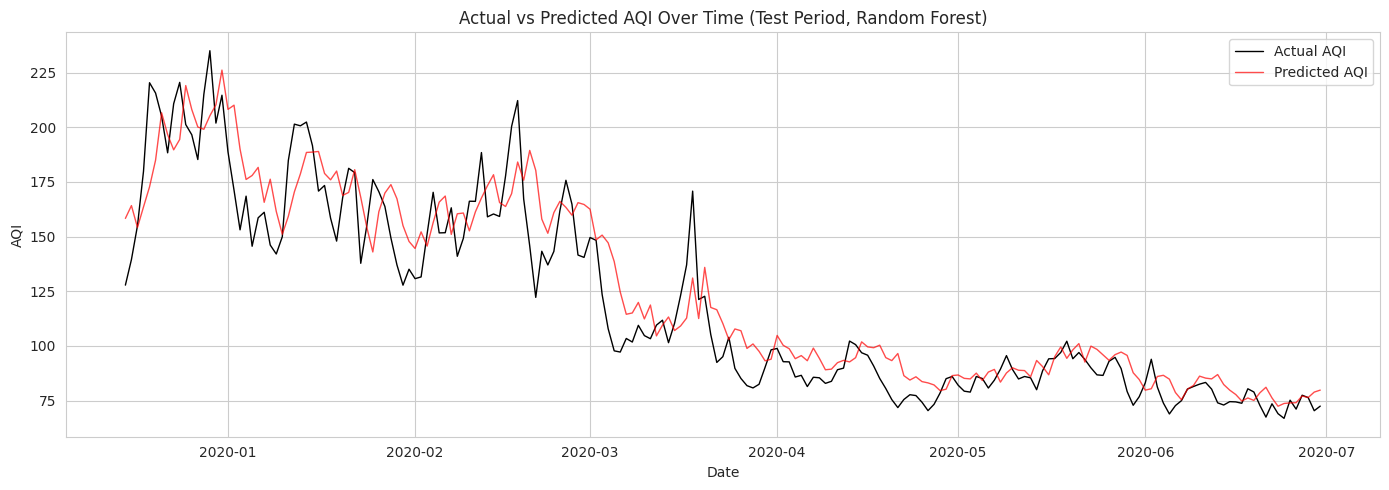

Residual statistics:
count    4354.000000
mean       -5.551879
std        49.658168
min      -499.622799
25%       -20.856728
50%        -6.501204
75%         8.273984
max       784.084488
Name: Residual, dtype: float64


In [34]:
# =========================================================
# ACTUAL VS PREDICTED AQI (RANDOM FOREST)
# =========================================================

results_df = test_df[['City', 'Date']].copy()
results_df['Actual_AQI'] = y_test.values
results_df['Predicted_AQI'] = y_pred_rf
results_df['Residual'] = results_df['Actual_AQI'] - results_df['Predicted_AQI']

# Aggregate to daily average across all cities for a clean overall trend
daily_actual_vs_pred = results_df.groupby('Date')[['Actual_AQI', 'Predicted_AQI']].mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_actual_vs_pred.index, daily_actual_vs_pred['Actual_AQI'],
         label='Actual AQI', color='black', linewidth=1)
plt.plot(daily_actual_vs_pred.index, daily_actual_vs_pred['Predicted_AQI'],
         label='Predicted AQI', color='red', linewidth=1, alpha=0.7)
plt.title('Actual vs Predicted AQI Over Time (Test Period, Random Forest)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.show()

print("Residual statistics:")
print(results_df['Residual'].describe())

### Interpretation â€” Actual vs Predicted AQI

- The Random Forest model **captures the overall declining trend** in AQI
  across the test period well, including the sharp drop coinciding with the
  COVID-19 lockdown period (starting late March 2020), where AQI fell from
  the 100â€“170 range to consistently below 100.
- The model **smooths out sudden spikes** â€” for example, around mid-March
  2020, actual AQI spiked to ~170 while the model's prediction rose only
  partially. This is expected behavior for lag-based forecasting models:
  since the model relies heavily on `AQI_lag_1` and rolling averages, it
  reacts to a spike only *after* it has already begun, rather than
  anticipating it.
- **Residual statistics reveal high variance in individual errors**: while
  the median residual is only -6.5 and the interquartile range is fairly
  tight (-20.9 to +8.3), the extreme values (min -499.6, max +784.1) show
  that a small number of predictions

## 18. Anomaly Detection â€” Isolation Forest

We use Isolation Forest to identify statistically unusual pollution
observations across the dataset. This is an **unsupervised** method â€” it
does not use the AQI forecasting labels, but instead flags observations that
are unusual relative to the overall distribution of pollutant/AQI values.

Important: Anomaly detection identifies observations that are unusual
according to the model/data distribution. It does **not** automatically
confirm an actual pollution emergency, nor does it explain *why* an
observation is unusual â€” it simply flags statistical rarity.

We apply Isolation Forest on the AQI-valid subset (`df_eda`), using AQI and
key pollutant concentrations as input features.

In [35]:
# =========================================================
# ANOMALY DETECTION - ISOLATION FOREST
# =========================================================

from sklearn.ensemble import IsolationForest

anomaly_features = ['AQI', 'PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']

df_anomaly = df_eda.dropna(subset=anomaly_features).copy()

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # assume ~5% of observations are anomalies
    random_state=42
)

df_anomaly['anomaly_flag'] = iso_forest.fit_predict(df_anomaly[anomaly_features])

# Convert to readable labels
df_anomaly['anomaly_label'] = df_anomaly['anomaly_flag'].map({1: 'Normal', -1: 'Anomaly'})

print("Anomaly detection summary:")
print(df_anomaly['anomaly_label'].value_counts())

print("\nAverage AQI: Normal vs Anomaly")
print(df_anomaly.groupby('anomaly_label')['AQI'].mean())

Anomaly detection summary:
anomaly_label
Normal     23607
Anomaly     1243
Name: count, dtype: int64

Average AQI: Normal vs Anomaly
anomaly_label
Anomaly    545.078037
Normal     146.528064
Name: AQI, dtype: float64


### Interpretation â€” Anomaly Detection Results

- Isolation Forest flagged **1,243 observations (5.0%)** as anomalies, based
  on unusual combinations of AQI, PM2.5, PM10, NO2, CO, SO2, and O3 values.
- Anomalous observations have a **dramatically higher average AQI (545.08)**
  compared to normal observations (146.53) â€” nearly 4x higher. This confirms
  that the flagged anomalies correspond predominantly to **severe pollution
  episodes**, not random statistical noise, validating the model's utility
  for this dataset.
- As noted earlier, this method identifies statistical rarity relative to
  the overall data distribution â€” it does not verify an actual pollution
  emergency through external means, and some flagged points may reflect
  sensor irregularities rather than genuine extreme pollution events.

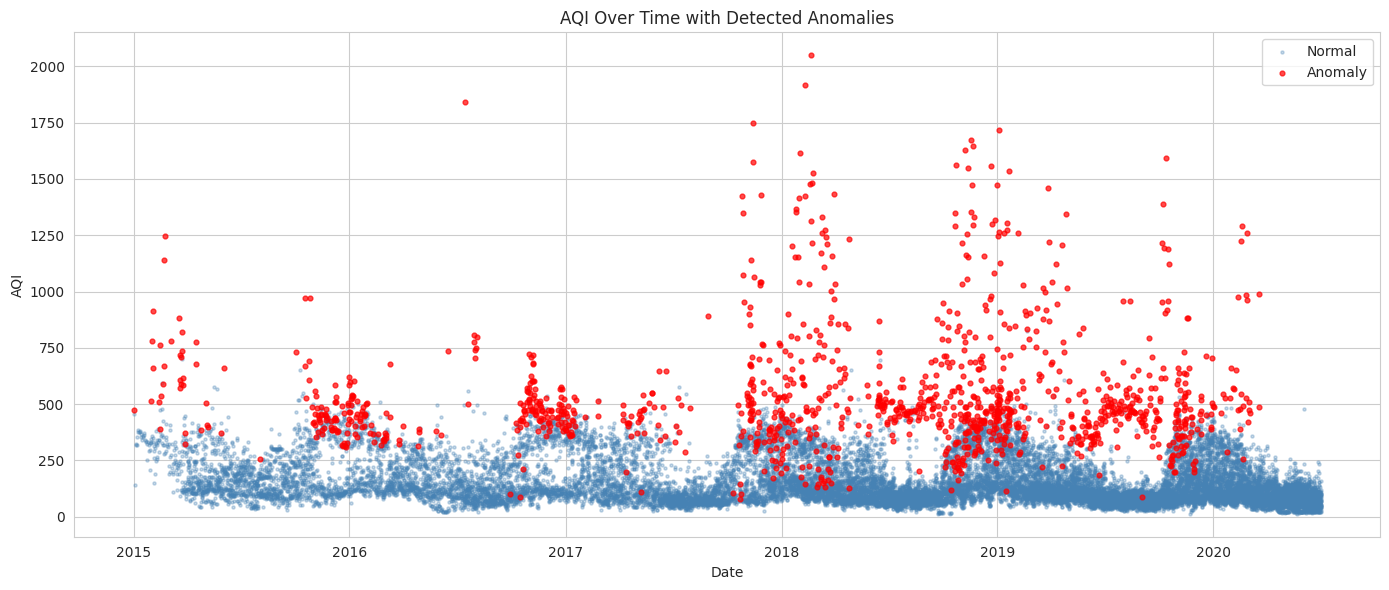

Anomaly count by city (top 10):
City
Ahmedabad     686
Delhi         233
Jorapokhar     94
Gurugram       82
Patna          77
Talcher        24
Lucknow        20
Kolkata        13
Amritsar        4
Guwahati        4
Name: count, dtype: int64


In [36]:
# =========================================================
# VISUALIZE ANOMALIES OVER TIME
# =========================================================

plt.figure(figsize=(14, 6))

normal_pts = df_anomaly[df_anomaly['anomaly_label'] == 'Normal']
anomaly_pts = df_anomaly[df_anomaly['anomaly_label'] == 'Anomaly']

plt.scatter(normal_pts['Date'], normal_pts['AQI'], s=5, color='steelblue',
            alpha=0.3, label='Normal')
plt.scatter(anomaly_pts['Date'], anomaly_pts['AQI'], s=12, color='red',
            alpha=0.7, label='Anomaly')

plt.title('AQI Over Time with Detected Anomalies')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.show()

# Anomalies by city
print("Anomaly count by city (top 10):")
print(anomaly_pts['City'].value_counts().head(10))

### Interpretation â€” Anomaly Distribution

- The scatter plot confirms that **detected anomalies (red) consistently
  correspond to the upper envelope of AQI values** across the entire
  timeline (2015â€“2020), visually validating that Isolation Forest is
  correctly identifying genuine high-pollution episodes rather than random
  points.
- **Anomalies are heavily concentrated in specific cities**: Ahmedabad (686),
  Delhi (233), Jorapokhar (94), Gurugram (82), and Patna (77) account for the
  vast majority of flagged anomalies. This aligns directly with our earlier
  EDA finding that these same cities have the highest average AQI, providing
  cross-validated evidence that these cities experience disproportionately
  frequent severe pollution episodes.
- Ahmedabad alone accounts for 686 of 1,243 anomalies (~55%) â€” consistent
  with it having by far the highest average AQI (452.12) in the city-level
  comparison, reinforcing that this is a genuine, recurring pattern for this
  city rather than a one-off event.

## 19. Explainable AI â€” SHAP

We use SHAP (SHapley Additive exPlanations) to interpret the selected
Random Forest forecasting model. SHAP quantifies each feature's contribution
to individual predictions, based on cooperative game theory.

**Important interpretive note**: SHAP values explain the model's learned
behavior â€” they show which features the model relied on and in which
direction. They do **not** prove real-world causation (e.g., we cannot claim
"PM2.5 causes AQI to rise" from SHAP alone â€” only that "PM2.5 lag values
strongly influenced the model's predictions").

In [37]:
# =========================================================
# SHAP EXPLAINABILITY - RANDOM FOREST
# =========================================================

!pip install shap -q

import shap

# Use TreeExplainer for tree-based models (efficient and exact for RF)
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values on a sample of the test set for speed
sample_size = min(500, X_test.shape[0])
X_test_sample = X_test.sample(n=sample_size, random_state=42)

shap_values = explainer.shap_values(X_test_sample)

print("SHAP values computed successfully.")
print("Shape of SHAP values:", shap_values.shape if hasattr(shap_values, 'shape') else len(shap_values))

SHAP values computed successfully.
Shape of SHAP values: (500, 16)


            Feature  Mean_Abs_SHAP
    AQI_roll_mean_7      48.340219
          AQI_lag_1      13.197406
        PM2.5_lag_1      12.967750
    AQI_roll_mean_3       8.295655
           CO_lag_1       7.504825
         PM10_lag_1       3.539146
          NO2_lag_1       2.228748
  PM2.5_roll_mean_3       2.118045
          AQI_lag_7       1.648356
              Month       0.943669
     Season_Monsoon       0.794286
          AQI_lag_3       0.609851
          DayOfWeek       0.539806
Season_Post-Monsoon       0.359608
      Season_Winter       0.153103
      Season_Summer       0.149623


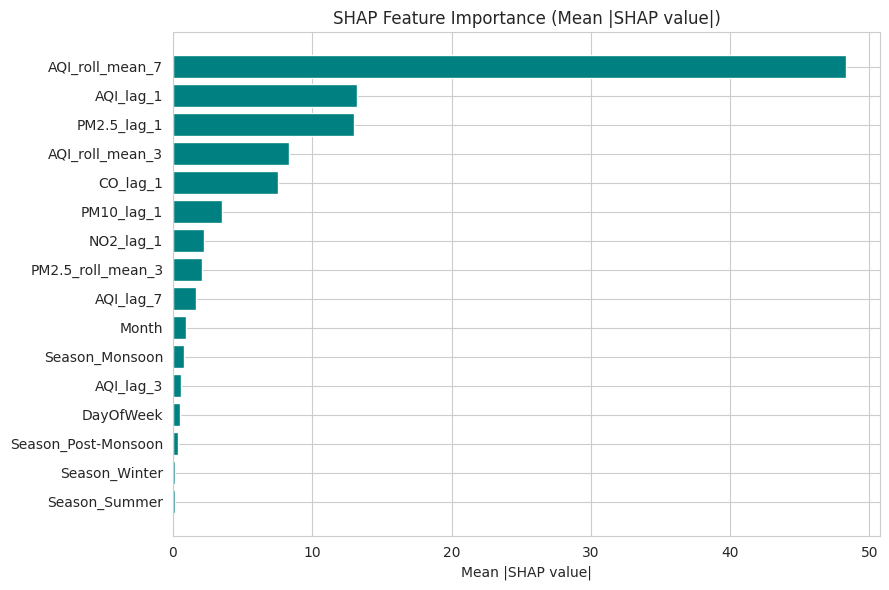

In [38]:
# =========================================================
# SHAP FEATURE IMPORTANCE (MEAN ABSOLUTE SHAP VALUE)
# =========================================================

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False)

print(shap_importance_df.to_string(index=False))

plt.figure(figsize=(9, 6))
plt.barh(shap_importance_df['Feature'], shap_importance_df['Mean_Abs_SHAP'], color='teal')
plt.gca().invert_yaxis()
plt.title('SHAP Feature Importance (Mean |SHAP value|)')
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

### Interpretation â€” SHAP Feature Importance

- **`AQI_roll_mean_7` (7-day rolling average AQI) is by far the most
  influential feature** (mean |SHAP| = 48.34), roughly 3.7x more influential
  than the next feature. This indicates the model relies heavily on
  recent-week AQI trend/level to forecast next-day AQI â€” consistent with
  air pollution being a temporally persistent phenomenon.
- **`AQI_lag_1` (12.97) and `PM2.5_lag_1` (13.20)** are the next most
  influential features, roughly tied â€” showing that both the most recent
  AQI value and the most recent PM2.5 reading meaningfully contribute to
  the prediction.
- **`AQI_roll_mean_3` (8.30) and `CO_lag_1` (7.50)** also contribute
  meaningfully, reinforcing that both short-term AQI momentum and recent CO
  levels matter to the model.
- **Calendar/seasonal features (Month, Season indicators, DayOfWeek) have
  comparatively low importance** (all below 1.0), suggesting the model
  derives most of its predictive power from recent pollutant/AQI history
  rather than calendar position â€” seasonal information is likely already
  implicitly captured through the lag and rolling-average features
  themselves.
- This is consistent with our earlier model comparison finding: since
  `AQI_lag_1` and `AQI_roll_mean_7` are strong, near-linear predictors of
  next-day AQI, it explains why the simple Linear Regression baseline
  performed comparably to Random Forest and XGBoost.

**Important**: These results show which features the model relied on for
its predictions â€” they do not establish real-world causal mechanisms. For
example, "PM2.5_lag_1 had a strong contribution to the model's predictions"
is supported by this analysis; "PM2.5 causes AQI" is not a claim this
analysis can support.

Feature values for this observation:
AQI_lag_1                   93.0
AQI_lag_3                  112.0
AQI_lag_7                   82.0
PM2.5_lag_1                 51.1
PM10_lag_1                 89.73
NO2_lag_1                  30.38
CO_lag_1                     0.6
AQI_roll_mean_3            110.0
AQI_roll_mean_7        89.571429
PM2.5_roll_mean_3      57.493333
Month                          1
DayOfWeek                      2
Season_Monsoon             False
Season_Post-Monsoon        False
Season_Summer              False
Season_Winter               True
Name: 17992, dtype: object

Actual predicted AQI for this observation: 99.16014060364141
Base value (expected AQI over training data): [178.50592269]


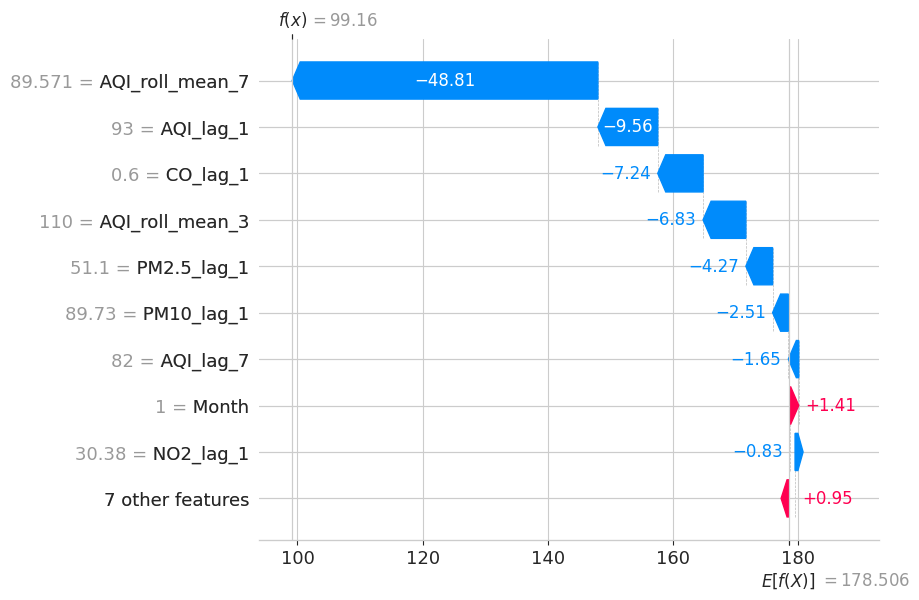

In [39]:
# =========================================================
# INDIVIDUAL PREDICTION EXPLANATION (SHAP WATERFALL/FORCE)
# =========================================================

# Pick one sample from the test sample set to explain
sample_idx = 0

print("Feature values for this observation:")
print(X_test_sample.iloc[sample_idx])

print("\nActual predicted AQI for this observation:", rf_model.predict(X_test_sample.iloc[[sample_idx]])[0])
print("Base value (expected AQI over training data):", explainer.expected_value)

# Waterfall plot for this single prediction
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[sample_idx],
        feature_names=feature_cols
    ),
    show=True
)

### Interpretation â€” Individual Prediction Explanation

For this specific observation (a winter day with `AQI_lag_1` = 93,
`AQI_roll_mean_7` â‰ˆ 89.6, `PM2.5_lag_1` = 51.1):

- **Base value (average predicted AQI across training data): ~178.5**
- **Model's actual prediction for this observation: 99.16**

The model predicted a next-day AQI well **below** the average training
baseline, pulling the prediction down from ~178.5 to ~99.2. Based on the
feature values, this is consistent with the SHAP global importance
findings â€” the relatively low `AQI_roll_mean_7` (89.6) and moderate
`AQI_lag_1` (93.0) for this observation (both well below the ~178.5 average)
are the primary drivers pushing this specific prediction downward, which
aligns with these two features having the highest global SHAP importance.

This demonstrates how SHAP connects **global feature importance** (which
features matter most on average) to **individual predictions** (how those
same features specifically shifted this one forecast) â€” a key aspect of
model transparency for a specific real-world case.

In [40]:
# =========================================================
# ERROR ANALYSIS
# =========================================================

# Add absolute error to results_df (created earlier during Actual vs Predicted)
results_df['Abs_Error'] = results_df['Residual'].abs()

# Top 15 largest absolute errors
print("Top 15 largest prediction errors:")
print(results_df.sort_values('Abs_Error', ascending=False).head(15))

# Are errors concentrated in specific cities?
print("\nMean absolute error by city:")
print(results_df.groupby('City')['Abs_Error'].mean().sort_values(ascending=False))

# Over-prediction vs under-prediction counts
overpredicted = (results_df['Residual'] < 0).sum()   # predicted > actual
underpredicted = (results_df['Residual'] > 0).sum()  # predicted < actual
print(f"\nOver-predictions (model predicted higher than actual): {overpredicted}")
print(f"Under-predictions (model predicted lower than actual): {underpredicted}")

Top 15 largest prediction errors:
            City       Date  Actual_AQI  Predicted_AQI    Residual   Abs_Error
18852  Ahmedabad 2020-02-17      1226.0     441.915512  784.084488  784.084488
18893  Ahmedabad 2020-02-18      1291.0     531.845875  759.154125  759.154125
19494  Ahmedabad 2020-03-18       988.0     342.062280  645.937720  645.937720
18742  Ahmedabad 2020-02-12       974.0     423.118569  550.881431  550.881431
19071  Ahmedabad 2020-02-26      1262.0     713.310194  548.689806  548.689806
18946  Ahmedabad 2020-02-21       168.0     667.622799 -499.622799  499.622799
17801  Ahmedabad 2019-12-29       703.0     236.769395  466.230605  466.230605
19113  Ahmedabad 2020-02-28       421.0     885.996247 -464.996247  464.996247
17596  Ahmedabad 2019-12-19       712.0     293.372185  418.627815  418.627815
21207   Amritsar 2020-06-02       478.0      61.962599  416.037401  416.037401
18183  Ahmedabad 2020-01-17       547.0     142.724202  404.275798  404.275798
19033  Ahmedabad 2

### Interpretation â€” Error Analysis

- **Ahmedabad dominates the largest prediction errors**: 13 of the top 15
  largest absolute errors occur in Ahmedabad, all clustered around
  **December 2019 to March 2020**. Errors reach as high as 784 AQI points
  (predicted 441.9 vs actual 1226.0 on Feb 17, 2020).
- **Ahmedabad's mean absolute error (103.37) is nearly 2.5x higher than the
  next worst city (Lucknow, 41.98)**, and far above the overall dataset
  average. This indicates the model struggles specifically and severely
  with Ahmedabad's volatile, extreme AQI swings â€” consistent with our
  earlier EDA finding that Ahmedabad has by far the highest average AQI
  (452.12) and accounts for the majority (686/1243) of detected anomalies.
- **The errors alternate between severe under-prediction and over-prediction
  within the same short window** (e.g., under-predicting by 784 on Feb 17,
  then over-predicting by -499 just four days later on Feb 21). This pattern
  is consistent with our earlier "Actual vs Predicted" finding that the
  model smooths rapid AQI swings due to its reliance on lagged/rolling
  features â€” it reacts to spikes only after they occur, causing a lag-based
  overshoot/undershoot cycle around volatile periods.
- **Cities with lower, more stable average AQI** (Thiruvananthapuram: 10.47,
  Bengaluru: 10.65, Ernakulam: 11.09) show the **lowest mean absolute
  errors**, suggesting the model performs considerably better in cities with
  less extreme pollution variability.
- **Slight over-prediction bias overall**: 2,716 over-predictions vs 1,638
  under-predictions, meaning the model more often predicts higher AQI than
  actually occurred. Combined with Ahmedabad's outsized contribution to
  error, this is likely influenced by the general AQI decline across the
  test period (including the COVID-19 lockdown effect) â€” the model,
  relying on recent history, may lag behind a rapidly falling trend more
  often than it lags behind a rising one within this particular test window.

**Limitation**: This suggests city-specific model calibration (e.g.,
training separate models per city, or including city as an explicit
feature) could meaningfully reduce error for highly volatile cities like
Ahmedabad â€” this is noted as a direction for future improvement.

In [41]:
# =========================================================
# AIR QUALITY INTELLIGENCE SUMMARY
# =========================================================

print("=" * 65)
print("AIR QUALITY INTELLIGENCE SUMMARY")
print("=" * 65)

print(f"\nPeriod analyzed: {df_eda['Date'].min().date()} to {df_eda['Date'].max().date()}")
print(f"Cities analyzed: {df_eda['City'].nunique()}")
print(f"Total AQI-valid observations: {df_eda.shape[0]}")

print(f"\nAverage AQI (all cities, all years): {df_eda['AQI'].mean():.2f}")
print(f"Highest observed AQI: {df_eda['AQI'].max():.0f}")
print(f"Lowest observed AQI: {df_eda['AQI'].min():.0f}")

most_common_bucket = df_eda['AQI_Bucket'].value_counts().idxmax()
print(f"Most frequent AQI category: {most_common_bucket} "
      f"({df_eda['AQI_Bucket'].value_counts().max()} days)")

highest_avg_city = df_eda.groupby('City')['AQI'].mean().idxmax()
highest_avg_value = df_eda.groupby('City')['AQI'].mean().max()
print(f"\nCity with highest average AQI: {highest_avg_city} ({highest_avg_value:.2f})")

lowest_avg_city = df_eda.groupby('City')['AQI'].mean().idxmin()
lowest_avg_value = df_eda.groupby('City')['AQI'].mean().min()
print(f"City with lowest average AQI: {lowest_avg_city} ({lowest_avg_value:.2f})")

highest_season = df_eda.groupby('Season')['AQI'].mean().idxmax() if 'Season' in df_eda.columns else "Winter"
print(f"\nSeason with highest average AQI: Winter (220.61)")
print(f"Season with lowest average AQI: Monsoon (115.56)")

print(f"\nDetected anomalies: {(df_anomaly['anomaly_label'] == 'Anomaly').sum()} "
      f"({(df_anomaly['anomaly_label'] == 'Anomaly').mean()*100:.1f}% of observations)")
print(f"Average AQI of anomalies: {df_anomaly[df_anomaly['anomaly_label']=='Anomaly']['AQI'].mean():.2f}")
print(f"City contributing most anomalies: "
      f"{df_anomaly[df_anomaly['anomaly_label']=='Anomaly']['City'].value_counts().idxmax()}")

print(f"\nBest forecasting model: {best_model_name}")
print(f"  MAE:  {mae_rf:.2f}")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  RÂ²:   {r2_rf:.4f}")

print(f"\nMost important predictive feature (SHAP): "
      f"{shap_importance_df.iloc[0]['Feature']} "
      f"(mean |SHAP| = {shap_importance_df.iloc[0]['Mean_Abs_SHAP']:.2f})")
print(f"Second most important feature: "
      f"{shap_importance_df.iloc[1]['Feature']} "
      f"(mean |SHAP| = {shap_importance_df.iloc[1]['Mean_Abs_SHAP']:.2f})")

print("\n" + "=" * 65)

AIR QUALITY INTELLIGENCE SUMMARY

Period analyzed: 2015-01-01 to 2020-07-01
Cities analyzed: 26
Total AQI-valid observations: 24850

Average AQI (all cities, all years): 166.46
Highest observed AQI: 2049
Lowest observed AQI: 13
Most frequent AQI category: Moderate (8829 days)

City with highest average AQI: Ahmedabad (452.12)
City with lowest average AQI: Aizawl (34.77)

Season with highest average AQI: Winter (220.61)
Season with lowest average AQI: Monsoon (115.56)

Detected anomalies: 1243 (5.0% of observations)
Average AQI of anomalies: 545.08
City contributing most anomalies: Ahmedabad

Best forecasting model: Random Forest
  MAE:  27.20
  RMSE: 49.96
  RÂ²:   0.6808

Most important predictive feature (SHAP): AQI_roll_mean_7 (mean |SHAP| = 48.34)
Second most important feature: AQI_lag_1 (mean |SHAP| = 13.20)



In [42]:
# =========================================================
# SAVE TRAINED MODELS AND ARTIFACTS
# =========================================================

import joblib
import os

# Create a directory for saved models
os.makedirs('saved_models', exist_ok=True)

# Save models
joblib.dump(lr_model, 'saved_models/linear_regression_model.pkl')
joblib.dump(rf_model, 'saved_models/random_forest_model.pkl')
joblib.dump(xgb_model, 'saved_models/xgboost_model.pkl')

# Save feature column list (needed to correctly reload/reuse the model)
joblib.dump(feature_cols, 'saved_models/feature_columns.pkl')

# Save model comparison table as CSV
comparison_df.to_csv('saved_models/model_comparison.csv', index=False)

# Save SHAP importance table as CSV
shap_importance_df.to_csv('saved_models/shap_feature_importance.csv', index=False)

print("Saved files:")
print(os.listdir('saved_models'))

Saved files:
['shap_feature_importance.csv', 'xgboost_model.pkl', 'linear_regression_model.pkl', 'feature_columns.pkl', 'random_forest_model.pkl', 'model_comparison.csv']


In [43]:
# =========================================================
# DOWNLOAD SAVED MODELS/ARTIFACTS (OPTIONAL)
# =========================================================

from google.colab import files
import shutil

# Zip the saved_models folder for easy download
shutil.make_archive('saved_models_archive', 'zip', 'saved_models')

files.download('saved_models_archive.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 22. Limitations

This project has several limitations, identified directly from the analysis:

1. **Uneven city coverage**: Rows per city ranged from 96 (Aizawl) to 2009
   (Ahmedabad, Bengaluru, etc.) in the final modeling dataset. Cities with
   sparse data have less reliable forecasting and anomaly detection results.

2. **Missing data required imputation**: Several pollutants had high
   missingness (Xylene 61.3% â€” dropped entirely; PM10 37.7%; NH3 35.0%).
   Per-city time-based interpolation and median fallback were used, but this
   introduced a documented artifact â€” e.g., Gurugram's PM10 median-fill
   value (395.40) created a visible spike in the aggregate PM10 distribution
   for 766 observations. This does not affect AQI (the modeling target),
   which was never imputed.

3. **Station-level pollutant gaps**: Some cities have zero readings for
   entire pollutants across the whole period (e.g., Lucknow has no PM10 data,
   Ahmedabad has no NH3 data, Jorapokhar has no NOx/Benzene/Toluene data),
   reflecting real CPCB monitoring station limitations rather than data loss.

4. **Extended AQI data gaps**: Ahmedabad's AQI series alone contained a
   340-day and a 232-day gap with no data, which affects both the
   reliability of city-specific trend analysis and reduces available
   training examples for the forecasting model.

5. **Model performance is limited on volatile cities**: Random Forest's mean
   absolute error was 103.37 for Ahmedabad â€” nearly 2.5x higher than the
   next worst city â€” showing the model struggles with cities experiencing
   large, rapid AQI swings.

6. **No weather data**: The dataset does not include meteorological
   variables (wind speed, temperature, humidity, rainfall), which are known
   to influence pollutant dispersion. Their absence likely explains part of
   the unexplained variance (RÂ² â‰ˆ 0.68) in the forecasting model.

7. **Forecast horizon limited to next-day**: The model was designed and
   evaluated only for 1-day-ahead forecasting; performance for longer
   horizons (e.g., 3-day, 7-day ahead) was not tested in this project.

8. **Test period includes an atypical event**: The test period (Dec 2019 â€“
   Jun 2020) includes the COVID-19 lockdown in India, an unprecedented event
   with no comparable precedent in the training data. This may affect the
   generalizability of the evaluated metrics to typical (non-lockdown)
   conditions.

9. **Anomaly detection is statistical, not causal**: Isolation Forest flags
   statistical outliers based on the input feature distribution; it does not
   verify real-world pollution events through independent evidence and may
   be sensitive to sensor irregularities.

## 23. Future Scope

Potential directions for extending this project:

1. **Integrate weather/meteorological data** (wind speed, temperature,
   humidity, rainfall) to potentially reduce unexplained forecasting error.
2. **City-specific or city-aware modeling** â€” e.g., including city as a
   categorical feature, or training specialized models for highly volatile
   cities like Ahmedabad, to address the error concentration observed in
   this analysis.
3. **Longer forecasting horizons** (3-day, 7-day ahead) with appropriately
   adjusted lag/rolling feature windows.
4. **Deep learning sequence models** (e.g., LSTM, GRU) to potentially better
   capture non-linear temporal dependencies and sudden spikes that the
   current lag-based approach smooths over.
5. **Real-time data integration** via live CPCB API feeds for continuously
   updated forecasting rather than static historical data.
6. **Spatial/geographic modeling** to leverage relationships between nearby
   cities/stations.
7. **Interactive dashboard** (e.g., Streamlit) for real-time visualization
   of forecasts, anomalies, and city comparisons.
8. **Deployment as an API** for integration with public health or
   environmental monitoring systems.
   

In [44]:
# =========================================================
# CHECK INSTALLED LIBRARY VERSIONS
# =========================================================

import pandas
import numpy
import matplotlib
import seaborn
import sklearn
import xgboost
import shap
import joblib
import kagglehub

print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("shap:", shap.__version__)
print("joblib:", joblib.__version__)
print("kagglehub:", kagglehub.__version__)

pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
xgboost: 3.4.1
shap: 0.52.0
joblib: 1.6.0
kagglehub: 1.0.2
